In [1]:
import warnings

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
import pandas as pd
import numpy as np
import random
import sc_toolbox
import pertpy 

import rpy2.rinterface_lib.callbacks
import anndata2ri
import logging

from rpy2.robjects import pandas2ri
from rpy2.robjects import r

sc.settings.verbosity = 0
rpy2.rinterface_lib.callbacks.logger.setLevel(logging.ERROR)

pandas2ri.activate()
anndata2ri.activate()

pd.set_option('display.max_columns', None)

%load_ext rpy2.ipython

In [2]:
%%R
library(GSA)
library(msigdbr)
library(fgsea)
library(tidyverse) # includes ggplot2, for data visualisation. dplyr, for data manipulation.
library(RColorBrewer) # for a colourful plot

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [3]:
%%R

set.seed(42)

# Figure out how to set up gene lists

In [4]:
%%R

all_gene_sets = msigdbr(species = "Mus musculus")
head(all_gene_sets)

# A tibble: 6 × 18
  gs_cat gs_subcat      gs_name        gene_symbol entrez_gene ensembl_gene     
  <chr>  <chr>          <chr>          <chr>             <int> <chr>            
1 C3     MIR:MIR_Legacy AAACCAC_MIR140 Abcc4            239273 ENSMUSG000000328…
2 C3     MIR:MIR_Legacy AAACCAC_MIR140 Abraxas2         109359 ENSMUSG000000309…
3 C3     MIR:MIR_Legacy AAACCAC_MIR140 Actn4             60595 ENSMUSG000000548…
4 C3     MIR:MIR_Legacy AAACCAC_MIR140 Acvr1             11477 ENSMUSG000000268…
5 C3     MIR:MIR_Legacy AAACCAC_MIR140 Adam9             11502 ENSMUSG000000315…
6 C3     MIR:MIR_Legacy AAACCAC_MIR140 Adamts5           23794 ENSMUSG000000228…
# ℹ 12 more variables: human_gene_symbol <chr>, human_entrez_gene <int>,
#   human_ensembl_gene <chr>, gs_id <chr>, gs_pmid <chr>, gs_geoid <chr>,
#   gs_exact_source <chr>, gs_url <chr>, gs_description <chr>, taxon_id <int>,
#   ortholog_sources <chr>, num_ortholog_sources <dbl>


In [5]:
%%R

# Get the MSigDB collections
collections <- msigdbr_collections()

# Print all rows of the tibble
print(collections, n = Inf)

# A tibble: 23 × 3
   gs_cat gs_subcat         num_genesets
   <chr>  <chr>                    <int>
 1 C1     ""                         299
 2 C2     "CGP"                     3384
 3 C2     "CP"                        29
 4 C2     "CP:BIOCARTA"              292
 5 C2     "CP:KEGG"                  186
 6 C2     "CP:PID"                   196
 7 C2     "CP:REACTOME"             1615
 8 C2     "CP:WIKIPATHWAYS"          664
 9 C3     "MIR:MIRDB"               2377
10 C3     "MIR:MIR_Legacy"           221
11 C3     "TFT:GTRD"                 518
12 C3     "TFT:TFT_Legacy"           610
13 C4     "CGN"                      427
14 C4     "CM"                       431
15 C5     "GO:BP"                   7658
16 C5     "GO:CC"                   1006
17 C5     "GO:MF"                   1738
18 C5     "HPO"                     5071
19 C6     ""                         189
20 C7     "IMMUNESIGDB"             4872
21 C7     "VAX"                      347
22 C8     ""                         7

In [6]:
%%R

#Retrieve human H (hallmark gene sets) 
msigdbr_df <- msigdbr(species = "mouse", category = "H")


head(msigdbr_df)

# A tibble: 6 × 18
  gs_cat gs_subcat gs_name               gene_symbol entrez_gene ensembl_gene   
  <chr>  <chr>     <chr>                 <chr>             <int> <chr>          
1 H      ""        HALLMARK_ADIPOGENESIS Abca1             11303 ENSMUSG0000001…
2 H      ""        HALLMARK_ADIPOGENESIS Abcb8             74610 ENSMUSG0000002…
3 H      ""        HALLMARK_ADIPOGENESIS Acaa2             52538 ENSMUSG0000003…
4 H      ""        HALLMARK_ADIPOGENESIS Acadl             11363 ENSMUSG0000002…
5 H      ""        HALLMARK_ADIPOGENESIS Acadm             11364 ENSMUSG0000006…
6 H      ""        HALLMARK_ADIPOGENESIS Acads             11409 ENSMUSG0000002…
# ℹ 12 more variables: human_gene_symbol <chr>, human_entrez_gene <int>,
#   human_ensembl_gene <chr>, gs_id <chr>, gs_pmid <chr>, gs_geoid <chr>,
#   gs_exact_source <chr>, gs_url <chr>, gs_description <chr>, taxon_id <int>,
#   ortholog_sources <chr>, num_ortholog_sources <dbl>


In [7]:
%%R

pathwaysH = split(x = msigdbr_df$gene_symbol, f = msigdbr_df$gs_name)
head(pathwaysH)

$HALLMARK_ADIPOGENESIS
  [1] "Abca1"    "Abcb8"    "Acaa2"    "Acadl"    "Acadm"    "Acads"   
  [7] "Acly"     "Aco2"     "Acox1"    "Adcy6"    "Adig"     "Adipoq"  
 [13] "Adipor2"  "Agpat3"   "Aifm1"    "Ak2"      "Aldh2"    "Aldoa"   
 [19] "Angpt1"   "Angptl4"  "Aplp2"    "Apoe"     "Araf"     "Arl4a"   
 [25] "Atl2"     "Atp1b3"   "Atp5o"    "Baz2a"    "Bckdha"   "Bcl2l13" 
 [31] "Bcl6"     "C3"       "Cat"      "Cavin1"   "Cavin2"   "Ccng2"   
 [37] "Cd151"    "Cd302"    "Cd36"     "Cdkn2c"   "Chchd10"  "Chuk"    
 [43] "Cidea"    "Cmbl"     "Cmpk1"    "Col15a1"  "Col4a1"   "Coq3"    
 [49] "Coq5"     "Coq9"     "Cox6a1"   "Cox7b"    "Cox8a"    "Cpt2"    
 [55] "Crat"     "Cs"       "Cyc1"     "Cyp4b1"   "Dbt"      "Ddt"     
 [61] "Decr1"    "Dgat1"    "Dhcr7"    "Dhrs7"    "Dhrs7b"   "Dlat"    
 [67] "Dld"      "Dnajb9"   "Dnajc15"  "Dram2"    "Ech1"     "Echs1"   
 [73] "Elmod3"   "Elovl6"   "Enpp2"    "Ephx2"    "Esrra"    "Esyt1"   
 [79] "Etfb"     "Fabp4"    "Fah"      "F

In [8]:
%%R

options(ports=8888)

# LPC_demyel BAMs

In [9]:
%%R

# Replace the file path with the actual path if the file is not in the current directory
df <- read.csv("./files/LPC_demyel_Mgctrl_v_BAMs_voom_wqw_NEW.csv")
head(df)  # Display the first few rows of the data frame to confirm it's loaded correctly

     gene     logFC  AveExpr         t      P.Value    adj.P.Val        B
1  Pard3b -6.676340 4.516703 -40.34751 1.539252e-14 1.506312e-10 22.87087
2 Rtn4rl1 -6.676376 3.781436 -32.70249 2.039465e-13 8.169610e-10 20.43870
3   Sall1 -7.238846 3.593838 -32.15979 2.504479e-13 8.169610e-10 20.22825
4 Slc40a1 -5.495487 3.272162 -29.80532 6.361467e-13 1.556333e-09 19.60854
5    Tjp1 -6.955847 3.821797 -28.12929 1.291834e-12 1.655170e-09 18.81722
6   Snta1 -4.428345 4.769659 -28.09160 1.313193e-12 1.655170e-09 19.26227


In [10]:
%%R

dim(df)

[1] 9786    7


In [11]:
%%R

my_genes <- df$gene
head(my_genes)

[1] "Pard3b"  "Rtn4rl1" "Sall1"   "Slc40a1" "Tjp1"    "Snta1"  


In [12]:
%%R
# Check column names in the dataframe
colnames(df)

[1] "gene"      "logFC"     "AveExpr"   "t"         "P.Value"   "adj.P.Val"
[7] "B"        


In [13]:
%%R

# Compute ranking score using all genes
df$ranking_score <- -log10(df$P.Value) * sign(df$logFC)

# Assign gene names
rankings <- df$ranking_score
names(rankings) <- df$gene

# Sort rankings
rankings <- sort(rankings, decreasing = TRUE)

In [14]:
%%R

length(rankings)

[1] 9786


In [15]:
%%R

# Ensure the length of the gene column matches the length of rankings
length(df$gene) == length(rankings)

[1] TRUE


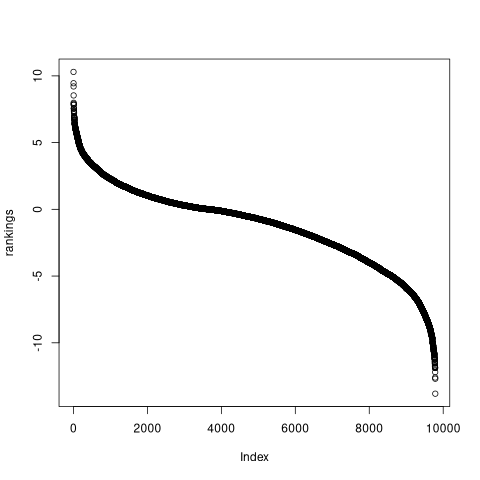

In [16]:
%%R

plot(rankings)

In [17]:
%%R

max(rankings)

[1] 10.29598


In [18]:
%%R

min(rankings)

[1] -13.81269


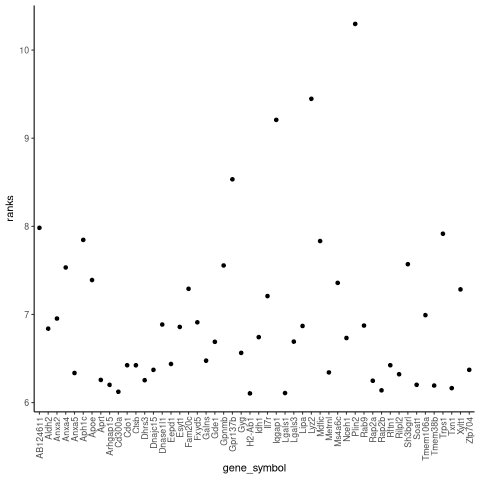

In [19]:
%%R

ggplot(data.frame(gene_symbol = names(rankings)[1:50], ranks = rankings[1:50]), aes(gene_symbol, ranks)) + 
    geom_point() +
    theme_classic() + 
    theme(axis.text.x = element_text(angle = 90, vjust = 0.5, hjust=1))

In [20]:
%%R

head(rankings)

    Plin2      Lyz2    Iqgap1   Gpr137b  AB124611     Trps1 
10.295978  9.446441  9.207441  8.533586  7.982759  7.915745 


## START BAM GSEA

In [40]:
%%R
fgsea_OPC <- fgsea(pathways = pathwaysH, 
                  stats    = rankings,
                  scoreType = 'std',
                  minSize  = 15,
                  maxSize  = 500)

In addition: Warning message:
In fgseaMultilevel(pathways = pathways, stats = stats, minSize = minSize,  :
  There were 8 pathways for which P-values were not calculated properly due to unbalanced (positive and negative) gene-level statistic values. For such pathways pval, padj, NES, log2err are set to NA. You can try to increase the value of the argument nPermSimple (for example set it nPermSimple = 10000)


In [41]:
%%R
fgsea_OPC

                                       pathway         pval        padj
                                        <char>        <num>       <num>
 1:                      HALLMARK_ADIPOGENESIS           NA          NA
 2:               HALLMARK_ALLOGRAFT_REJECTION 2.871486e-01 0.657975460
 3:                 HALLMARK_ANDROGEN_RESPONSE 4.563895e-02 0.148185484
 4:                   HALLMARK_APICAL_JUNCTION 4.939516e-02 0.148185484
 5:                         HALLMARK_APOPTOSIS           NA          NA
 6:              HALLMARK_BILE_ACID_METABOLISM 9.571578e-01 1.000000000
 7:           HALLMARK_CHOLESTEROL_HOMEOSTASIS 1.194635e-04 0.002329538
 8:                       HALLMARK_COAGULATION 7.607362e-01 1.000000000
 9:                        HALLMARK_COMPLEMENT 9.799398e-01 1.000000000
10:                        HALLMARK_DNA_REPAIR           NA          NA
11:                       HALLMARK_E2F_TARGETS 9.198397e-01 1.000000000
12: HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION 8.423455e-03 0.04

In [42]:
%%R

# Filter for significant results with padj < 0.05
fgsea_OPC_significant <- fgsea_OPC %>% filter(padj < 0.1)
dim(fgsea_OPC_significant)

[1] 8 8


In [43]:
%%R
unique(fgsea_OPC_significant$pathway)

[1] "HALLMARK_CHOLESTEROL_HOMEOSTASIS"          
[2] "HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION"
[3] "HALLMARK_KRAS_SIGNALING_DN"                
[4] "HALLMARK_MITOTIC_SPINDLE"                  
[5] "HALLMARK_REACTIVE_OXYGEN_SPECIES_PATHWAY"  
[6] "HALLMARK_TGF_BETA_SIGNALING"               
[7] "HALLMARK_TNFA_SIGNALING_VIA_NFKB"          
[8] "HALLMARK_UV_RESPONSE_DN"                   


## Explore specific gene sets

In [47]:
%%R

fgseaResTidy <- fgsea_OPC %>%
  as_tibble() %>%
  arrange(desc(NES))

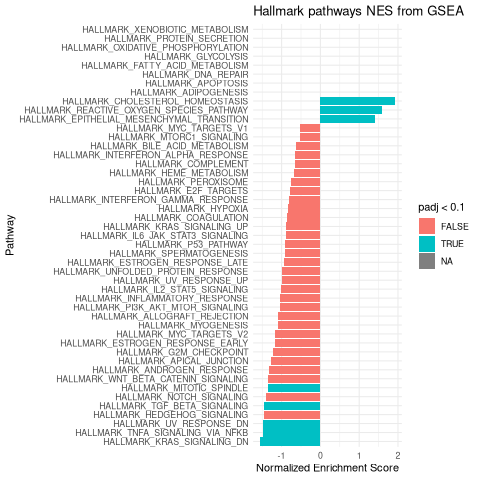

In [48]:
%%R

ggplot(fgseaResTidy, aes(reorder(pathway, NES), NES)) +
  geom_col(aes(fill=padj<0.1)) +
  coord_flip() +
  labs(x="Pathway", y="Normalized Enrichment Score",
       title="Hallmark pathways NES from GSEA") + 
  theme_minimal()


#https://stephenturner.github.io/deseq-to-fgsea/#using_the_fgsea_package

In [52]:
%%R

# Subset significant results
fgseaResSignificant <- fgseaResTidy[fgseaResTidy$padj < 0.05, ]

# Select columns to display and sort by padj
fgseaResSignificant <- fgseaResSignificant[, c("pathway", "padj", "NES", "size")]
fgseaResSignificant <- fgseaResSignificant[order(fgseaResSignificant$padj), ]

# Print the table
head(fgseaResSignificant)

# A tibble: 6 × 4
  pathway                                     padj   NES  size
  <chr>                                      <dbl> <dbl> <int>
1 HALLMARK_CHOLESTEROL_HOMEOSTASIS         0.00233  1.93    43
2 HALLMARK_TNFA_SIGNALING_VIA_NFKB         0.00233 -1.49   157
3 HALLMARK_UV_RESPONSE_DN                  0.0204  -1.49    93
4 HALLMARK_REACTIVE_OXYGEN_SPECIES_PATHWAY 0.0336   1.58    45
5 HALLMARK_MITOTIC_SPINDLE                 0.0336  -1.35   150
6 HALLMARK_KRAS_SIGNALING_DN               0.0336  -1.56    40


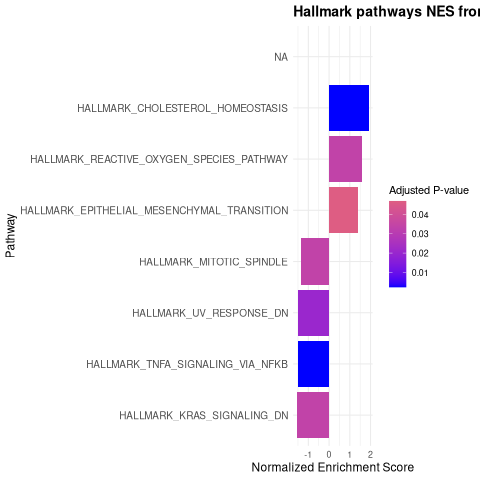

In [53]:
%%R

# Create the ggplot with a color scale for padj
ggplot(fgseaResSignificant, aes(reorder(pathway, NES), NES)) +
  geom_col(aes(fill = padj)) +
  coord_flip() +
  scale_fill_gradient(low = "#0000FF", high = "#de5d83", na.value = "black", name = "Adjusted P-value") +
  labs(x = "Pathway", y = "Normalized Enrichment Score",
       title = "Hallmark pathways NES from GSEA") +
  theme_minimal() +
  theme(
    axis.text.y = element_text(size = 10),
    axis.title = element_text(size = 12),
    plot.title = element_text(size = 14, face = "bold")
  )

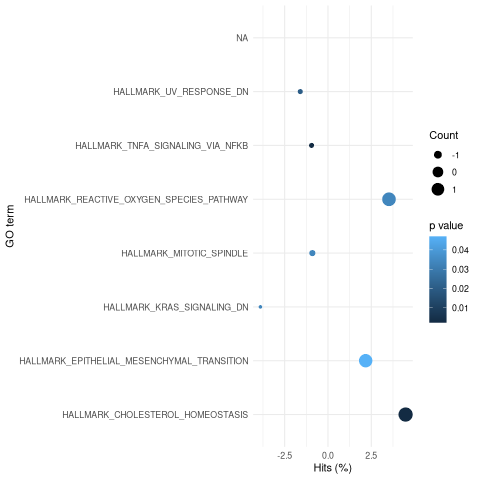

In [54]:
%%R

# Calculate hits percentage (if 'numDEInCat' and 'numInCat' equivalent are 'NES' and 'size')
fgseaResSignificant <- fgseaResSignificant %>%
  mutate(hitsPerc = NES * 100 / size)

# Ensure the columns 'padj' and 'NES' are present for the plot
fgseaResSignificant <- fgseaResSignificant %>%
  rename(term = pathway, over_represented_pvalue = padj, numDEInCat = NES)

# Create the plot
ggplot(fgseaResSignificant, aes(x = hitsPerc, y = term, colour = over_represented_pvalue, size = numDEInCat)) +
  geom_point() +
  expand_limits(x = 0) +
  labs(x = "Hits (%)", y = "GO term", colour = "p value", size = "Count") +
  theme_minimal()

#https://bioinformatics-core-shared-training.github.io/cruk-summer-school-2018/RNASeq2018/html/06_Gene_set_testing.nb.html

In [55]:
%%R

fgsea_OPC_significant

                                      pathway         pval        padj
                                       <char>        <num>       <num>
1:           HALLMARK_CHOLESTEROL_HOMEOSTASIS 1.194635e-04 0.002329538
2: HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION 8.423455e-03 0.046930680
3:                 HALLMARK_KRAS_SIGNALING_DN 5.175778e-03 0.033642555
4:                   HALLMARK_MITOTIC_SPINDLE 4.358898e-03 0.033642555
5:   HALLMARK_REACTIVE_OXYGEN_SPECIES_PATHWAY 4.515424e-03 0.033642555
6:                HALLMARK_TGF_BETA_SIGNALING 1.187736e-02 0.057902132
7:           HALLMARK_TNFA_SIGNALING_VIA_NFKB 6.041227e-05 0.002329538
8:                    HALLMARK_UV_RESPONSE_DN 1.569603e-03 0.020404844
     log2err         ES       NES  size
       <num>      <num>     <num> <int>
1: 0.5384341  0.4671657  1.925241    43
2: 0.3807304  0.3134921  1.414189    65
3: 0.4070179 -0.5698359 -1.559162    40
4: 0.4070179 -0.4486624 -1.353193   150
5: 0.4070179  0.3927656  1.583780    45
6: 0.38073

In [56]:
%%R

collapsedPathways <- collapsePathways(fgsea_OPC_significant[order(pval)][padj < 0.05], 
                                      pathwaysH, rankings)

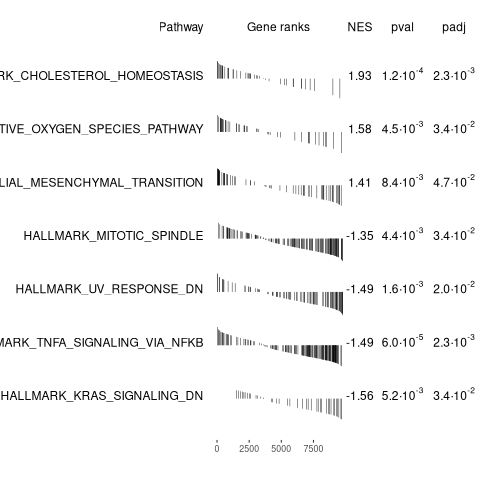

In [57]:
%%R

mainPathways <- fgsea_OPC_significant[pathway %in% collapsedPathways$mainPathways][
                         order(-NES), pathway]
plotGseaTable(pathwaysH[mainPathways], rankings, fgsea_OPC_significant, 
              gseaParam = 0.5)

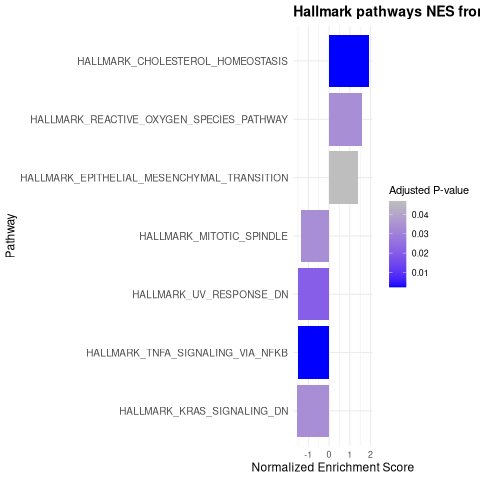

In [59]:
%%R

# Filter fgseaResSignificant to include only the main pathways from collapsedPathways
filtered_fgsea_OPC_significant <- fgsea_OPC_significant %>%
  filter(pathway %in% collapsedPathways$mainPathways)

# Create the ggplot with a color scale for padj
ggplot(filtered_fgsea_OPC_significant, aes(reorder(pathway, NES), NES)) +
  geom_col(aes(fill = padj)) +
  coord_flip() +
  scale_fill_gradient(low = "blue", high = "grey", na.value = "black", name = "Adjusted P-value") +
  labs(x = "Pathway", y = "Normalized Enrichment Score",
       title = "Hallmark pathways NES from GSEA") +
  theme_minimal() +
  theme(
    axis.text.y = element_text(size = 10),
    axis.title = element_text(size = 12),
    plot.title = element_text(size = 14, face = "bold")
  )


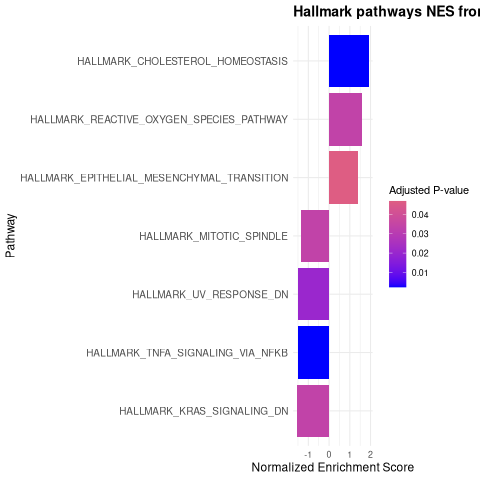

In [61]:
%%R

# Create the ggplot with a color scale for padj
ggplot(filtered_fgsea_OPC_significant, aes(reorder(pathway, NES), NES)) +
  geom_col(aes(fill = padj)) +
  coord_flip() +
  scale_fill_gradient(low = "#0000FF", high = "#de5d83", na.value = "black", name = "Adjusted P-value") +
  labs(x = "Pathway", y = "Normalized Enrichment Score",
       title = "Hallmark pathways NES from GSEA") +
  theme_minimal() +
  theme(
    axis.text.y = element_text(size = 10),
    axis.title = element_text(size = 12),
    plot.title = element_text(size = 14, face = "bold")
  )

In [62]:
%%R

# Remove "HALLMARK_" prefix from the 'pathway' column
filtered_fgsea_OPC_significant$pathway <- gsub("^HALLMARK_", "", filtered_fgsea_OPC_significant$pathway)

# View the updated heatmap_df
head(filtered_fgsea_OPC_significant)

                             pathway         pval        padj   log2err
                              <char>        <num>       <num>     <num>
1:           CHOLESTEROL_HOMEOSTASIS 1.194635e-04 0.002329538 0.5384341
2: EPITHELIAL_MESENCHYMAL_TRANSITION 8.423455e-03 0.046930680 0.3807304
3:                 KRAS_SIGNALING_DN 5.175778e-03 0.033642555 0.4070179
4:                   MITOTIC_SPINDLE 4.358898e-03 0.033642555 0.4070179
5:   REACTIVE_OXYGEN_SPECIES_PATHWAY 4.515424e-03 0.033642555 0.4070179
6:           TNFA_SIGNALING_VIA_NFKB 6.041227e-05 0.002329538 0.5573322
           ES       NES  size                               leadingEdge
        <num>     <num> <int>                                    <list>
1:  0.4671657  1.925241    43  Lgals3,Anxa5,Alcam,Fabp5,Gusb,Plscr1,...
2:  0.3134921  1.414189    65      Lgals1,Spp1,Capg,Mmp14,Tgfbi,Vim,...
3: -0.5698359 -1.559162    40     Msh5,Snn,Kcnd1,Lfng,Ccdc106,Nr6a1,...
4: -0.4486624 -1.353193   150 Arap3,Rapgef5,Bin1,Farp1,Arhgap5,S

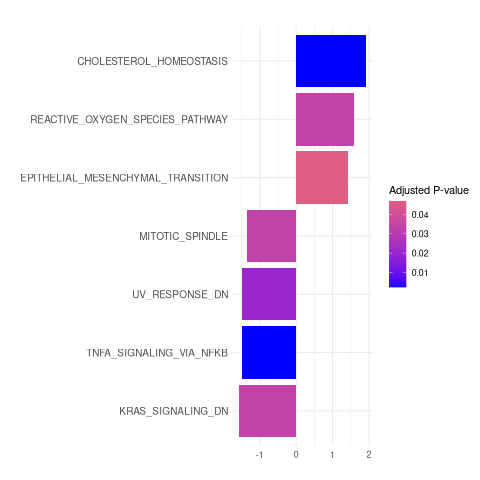

In [63]:
%%R

# Create the ggplot
plot <- ggplot(filtered_fgsea_OPC_significant, aes(reorder(pathway, NES), NES)) +
  geom_col(aes(fill = padj)) +
  coord_flip() +
  scale_fill_gradient(low = "#0000FF", high = "#de5d83", na.value = "black", name = "Adjusted P-value") +
  labs(x = "", y = "",
       title = "") +
  theme_minimal() +
  theme(
    axis.text.y = element_text(size = 10),
    axis.title = element_text(size = 12),
    plot.title = element_text(size = 14, face = "bold")
  )

# Save the plot as a high-resolution PNG file
#ggsave("./figures/GSEA/LPC_demyel_BAM_hallmark_pathways_NES_GSEA.png", plot = plot, dpi = 300, width = 10, height = 8)

print(plot)

In [38]:
%%R

head(filtered_fgsea_OPC_significant)

                             pathway         pval       padj   log2err
                              <char>        <num>      <num>     <num>
1:           CHOLESTEROL_HOMEOSTASIS 0.0002380395 0.00464177 0.5188481
2: EPITHELIAL_MESENCHYMAL_TRANSITION 0.0084152264 0.04688483 0.3807304
3:                 KRAS_SIGNALING_DN 0.0051404151 0.03341270 0.4070179
4:                   MITOTIC_SPINDLE 0.0049500175 0.03341270 0.4070179
5:   REACTIVE_OXYGEN_SPECIES_PATHWAY 0.0029663272 0.02892169 0.4317077
6:           TNFA_SIGNALING_VIA_NFKB 0.0001306298 0.00464177 0.5188481
           ES       NES  size                               leadingEdge
        <num>     <num> <int>                                    <list>
1:  0.4671657  1.915787    43  Lgals3,Anxa5,Alcam,Fabp5,Gusb,Plscr1,...
2:  0.3134921  1.379223    65      Lgals1,Spp1,Capg,Mmp14,Tgfbi,Vim,...
3: -0.5698359 -1.552856    40     Msh5,Snn,Kcnd1,Lfng,Ccdc106,Nr6a1,...
4: -0.4486624 -1.359103   150 Arap3,Rapgef5,Bin1,Farp1,Arhgap5,Sun2,...


In [39]:
%%R
unique(filtered_fgsea_OPC_significant$pathway)

[1] "CHOLESTEROL_HOMEOSTASIS"           "EPITHELIAL_MESENCHYMAL_TRANSITION"
[3] "KRAS_SIGNALING_DN"                 "MITOTIC_SPINDLE"                  
[5] "REACTIVE_OXYGEN_SPECIES_PATHWAY"   "TNFA_SIGNALING_VIA_NFKB"          
[7] "UV_RESPONSE_DN"                   


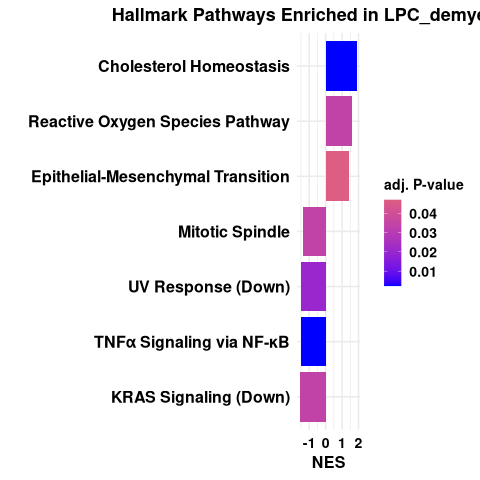

In [65]:
%%R

# Define your selected pathways and their pretty names
pathway_name_format <- c(
  "CHOLESTEROL_HOMEOSTASIS"           = "Cholesterol Homeostasis",
  "EPITHELIAL_MESENCHYMAL_TRANSITION" = "Epithelial-Mesenchymal Transition",
  "KRAS_SIGNALING_DN"                 = "KRAS Signaling (Down)",
  "MITOTIC_SPINDLE"                   = "Mitotic Spindle",
  "REACTIVE_OXYGEN_SPECIES_PATHWAY"   = "Reactive Oxygen Species Pathway",
  "TNFA_SIGNALING_VIA_NFKB"           = "TNFα Signaling via NF-κB",
  "UV_RESPONSE_DN"                    = "UV Response (Down)"
)

# Filter only the selected pathways and apply pretty names
filtered_fgsea_OPC_significant <- filtered_fgsea_OPC_significant %>%
  filter(pathway %in% names(pathway_name_format)) %>%
  mutate(pretty_pathway = pathway_name_format[pathway])

# Create the improved ggplot
plot <- ggplot(filtered_fgsea_OPC_significant, aes(reorder(pretty_pathway, NES), NES)) +
  geom_col(aes(fill = padj)) +
  coord_flip() +
  scale_fill_gradient(
    low = "#0000FF",
    high = "#de5d83",
    na.value = "black",
    name = "adj. P-value"
  ) +
  labs(
    x = "",
    y = "NES",
    title = "Hallmark Pathways Enriched in LPC_demyel PVMs"
  ) +
  theme_minimal(base_size = 16) +
  theme(
    axis.text.y = element_text(size = 16, face = "bold", color = "black"),
    axis.text.x = element_text(size = 14, face = "bold", color = "black"),
    axis.title = element_text(size = 16, face = "bold", color = "black"),
    plot.title = element_text(size = 18, face = "bold", color = "black", hjust = 0.5),
    legend.title = element_text(size = 14, face = "bold", color = "black"),
    legend.text = element_text(size = 14, face = "bold", color = "black")
  )

# Save high-resolution PNG
ggsave("./figures/GSEA/PVMs_LPCde_selected_hallmark_pathways_NES_GSEA.png",
       plot = plot, dpi = 300, width = 10, height = 8)

print(plot)

In [ ]:
%%R

# Define the pathway of interest
pathway_of_interest <- "CHOLESTEROL_HOMEOSTASIS"

# Subset the data to get the row with the specified pathway
selected_row <- filtered_fgsea_OPC_significant[filtered_fgsea_OPC_significant$pathway == pathway_of_interest, ]

# Extract the leadingEdge column as a list of gene symbols
leading_edge_genes <- unlist(selected_row$leadingEdge)

# Print the list of genes
print(leading_edge_genes)

In [ ]:
%%R

# Define the pathway of interest
pathway_of_interest <- "MITOTIC_SPINDLE"

# Subset the data to get the row with the specified pathway
selected_row <- filtered_fgsea_OPC_significant[filtered_fgsea_OPC_significant$pathway == pathway_of_interest, ]

# Extract the leadingEdge column as a list of gene symbols
leading_edge_genes <- unlist(selected_row$leadingEdge)

# Print the list of genes
print(leading_edge_genes)

In [ ]:
%%R

# Define the pathway of interest
pathway_of_interest <- "TNFA_SIGNALING_VIA_NFKB"

# Subset the data to get the row with the specified pathway
selected_row <- filtered_fgsea_OPC_significant[filtered_fgsea_OPC_significant$pathway == pathway_of_interest, ]

# Extract the leadingEdge column as a list of gene symbols
leading_edge_genes <- unlist(selected_row$leadingEdge)

# Print the list of genes
print(leading_edge_genes)

In [ ]:
%%R

# Define the pathway of interest
pathway_of_interest <- "KRAS_SIGNALING_DN"

# Subset the data to get the row with the specified pathway
selected_row <- filtered_fgsea_OPC_significant[filtered_fgsea_OPC_significant$pathway == pathway_of_interest, ]

# Extract the leadingEdge column as a list of gene symbols
leading_edge_genes <- unlist(selected_row$leadingEdge)

# Print the list of genes
print(leading_edge_genes)

In [ ]:
%%R

# Define the pathway of interest
pathway_of_interest <- "REACTIVE_OXYGEN_SPECIES_PATHWAY"

# Subset the data to get the row with the specified pathway
selected_row <- filtered_fgsea_OPC_significant[filtered_fgsea_OPC_significant$pathway == pathway_of_interest, ]

# Extract the leadingEdge column as a list of gene symbols
leading_edge_genes <- unlist(selected_row$leadingEdge)

# Print the list of genes
print(leading_edge_genes)

In [ ]:
%%R

# Define the pathway of interest
pathway_of_interest <- "UV_RESPONSE_DN"

# Subset the data to get the row with the specified pathway
selected_row <- filtered_fgsea_OPC_significant[filtered_fgsea_OPC_significant$pathway == pathway_of_interest, ]

# Extract the leadingEdge column as a list of gene symbols
leading_edge_genes <- unlist(selected_row$leadingEdge)

# Print the list of genes
print(leading_edge_genes)

In [68]:
%%R

class(filtered_fgsea_OPC_significant)

[1] "data.table" "data.frame"


In [69]:
%%R

class(fgsea_OPC)

[1] "data.table" "data.frame"


In [70]:
%%R

filtered_fgsea_OPC_significant <- as.data.frame(filtered_fgsea_OPC_significant)

In [71]:
%%R
filtered_fgsea_OPC_significant

                            pathway         pval        padj   log2err
1           CHOLESTEROL_HOMEOSTASIS 1.194635e-04 0.002329538 0.5384341
2 EPITHELIAL_MESENCHYMAL_TRANSITION 8.423455e-03 0.046930680 0.3807304
3                 KRAS_SIGNALING_DN 5.175778e-03 0.033642555 0.4070179
4                   MITOTIC_SPINDLE 4.358898e-03 0.033642555 0.4070179
5   REACTIVE_OXYGEN_SPECIES_PATHWAY 4.515424e-03 0.033642555 0.4070179
6           TNFA_SIGNALING_VIA_NFKB 6.041227e-05 0.002329538 0.5573322
7                    UV_RESPONSE_DN 1.569603e-03 0.020404844 0.4550599
          ES       NES size
1  0.4671657  1.925241   43
2  0.3134921  1.414189   65
3 -0.5698359 -1.559162   40
4 -0.4486624 -1.353193  150
5  0.3927656  1.583780   45
6 -0.4924311 -1.489465  157
7 -0.5015749 -1.485628   93
                                                                                                                                                                                                                

In [72]:
%%R
library(data.table)
fwrite(filtered_fgsea_OPC_significant, file = "./files/filtered_fgsea_LPC_demyel_BAM_significant_allgene.csv")

In [73]:
%%R

fwrite(fgsea_OPC, file = "./files/fgsea_LPC_demyel_BAM_all_allgene.csv")

# LPC_demyel_DAMs

In [74]:
%%R

# Replace the file path with the actual path if the file is not in the current directory
df <- read.csv("./files/LPC_demyel_bulk_MG_voom_wqw_NEW.csv")
head(df)  # Display the first few rows of the data frame to confirm it's loaded correctly

           gene     logFC  AveExpr         t      P.Value    adj.P.Val        B
1 C430049B03Rik -4.976612 3.042024 -18.77728 3.021768e-10 1.752826e-06 13.75054
2       Tspan18 -4.530556 2.880624 -18.74287 3.086777e-10 1.752826e-06 13.66724
3        Cacnb2 -4.979913 6.100542 -17.61170 6.347285e-10 1.954926e-06 13.36703
4         Cdkl4 -4.175601 2.783827 -17.00546 9.510145e-10 1.954926e-06 12.42529
5      Slc39a12 -5.351703 1.093420 -16.82386 1.076265e-09 1.954926e-06 12.05560
6       Clec4a2 -3.676323 3.195312 -16.57311 1.279375e-09 1.954926e-06 12.44555


In [75]:
%%R

dim(df)

[1] 11357     7


In [76]:
%%R

my_genes <- df$gene
head(my_genes)

[1] "C430049B03Rik" "Tspan18"       "Cacnb2"        "Cdkl4"        
[5] "Slc39a12"      "Clec4a2"      


In [77]:
%%R
# Check column names in the dataframe
colnames(df)

[1] "gene"      "logFC"     "AveExpr"   "t"         "P.Value"   "adj.P.Val"
[7] "B"        


In [78]:
%%R

# Compute ranking score using all genes
df$ranking_score <- -log10(df$P.Value) * sign(df$logFC)

# Assign gene names
rankings <- df$ranking_score
names(rankings) <- df$gene

# Sort rankings
rankings <- sort(rankings, decreasing = TRUE)

In [79]:
%%R

# Ensure the length of the gene column matches the length of rankings
length(df$gene) == length(rankings)

[1] TRUE


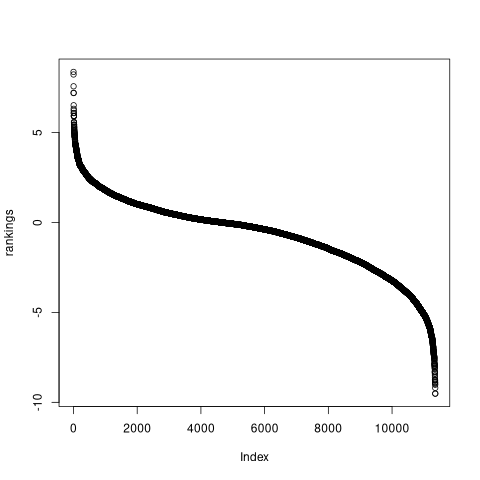

In [80]:
%%R

plot(rankings)

In [81]:
%%R

max(rankings)

[1] 8.362629


In [82]:
%%R

min(rankings)

[1] -9.519739


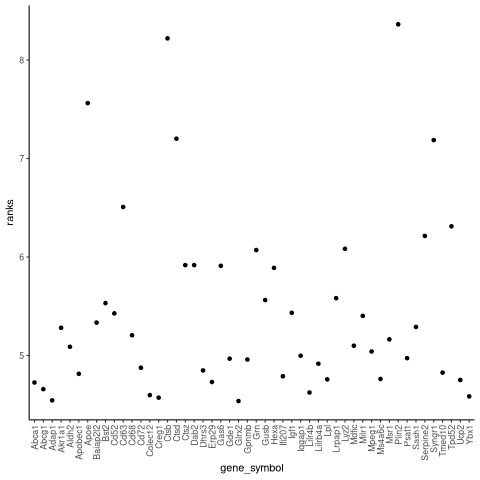

In [83]:
%%R

ggplot(data.frame(gene_symbol = names(rankings)[1:50], ranks = rankings[1:50]), aes(gene_symbol, ranks)) + 
    geom_point() +
    theme_classic() + 
    theme(axis.text.x = element_text(angle = 90, vjust = 0.5, hjust=1))

# Figure out how to set up gene lists

In [84]:
%%R
fgsea_res <- fgsea(pathways = pathwaysH, 
                  stats    = rankings,
                  scoreType = 'std',
                  minSize  = 15,
                  maxSize  = 500)

In addition: Warning message:
In fgseaMultilevel(pathways = pathways, stats = stats, minSize = minSize,  :
  There were 13 pathways for which P-values were not calculated properly due to unbalanced (positive and negative) gene-level statistic values. For such pathways pval, padj, NES, log2err are set to NA. You can try to increase the value of the argument nPermSimple (for example set it nPermSimple = 10000)


In [85]:
%%R
fgsea_res

                                       pathway         pval         padj
                                        <char>        <num>        <num>
 1:                      HALLMARK_ADIPOGENESIS           NA           NA
 2:               HALLMARK_ALLOGRAFT_REJECTION 8.824121e-01 0.9772727273
 3:                 HALLMARK_ANDROGEN_RESPONSE 2.184265e-01 0.4637647059
 4:                      HALLMARK_ANGIOGENESIS 2.085008e-02 0.0986802030
 5:                   HALLMARK_APICAL_JUNCTION 7.874494e-01 0.9772727273
 6:                    HALLMARK_APICAL_SURFACE 7.171838e-01 0.9772727273
 7:                         HALLMARK_APOPTOSIS           NA           NA
 8:              HALLMARK_BILE_ACID_METABOLISM 7.960458e-01 0.9772727273
 9:           HALLMARK_CHOLESTEROL_HOMEOSTASIS 5.289145e-04 0.0095204611
10:                       HALLMARK_COAGULATION 9.027307e-02 0.2499869579
11:                        HALLMARK_COMPLEMENT           NA           NA
12:                        HALLMARK_DNA_REPAIR     

In [86]:
%%R

library(data.table)
fwrite(fgsea_res, file = "./files/fgsea_LPC_demyel_DAMs_allgenes.csv")

In [87]:
%%R

dim(fgsea_res)

[1] 49  8


In [88]:
%%R

# Filter for significant results with padj < 0.05
fgsea_MOL2_significant <- fgsea_res %>% filter(padj < 0.1)
dim(fgsea_MOL2_significant)

[1] 10  8


In [89]:
%%R

head(fgsea_MOL2_significant)

                                      pathway         pval        padj
                                       <char>        <num>       <num>
1:                      HALLMARK_ANGIOGENESIS 0.0208500806 0.098680203
2:           HALLMARK_CHOLESTEROL_HOMEOSTASIS 0.0005289145 0.009520461
3: HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION 0.0017532688 0.021039226
4:                HALLMARK_HEDGEHOG_SIGNALING 0.0131219082 0.078731449
5:                   HALLMARK_HEME_METABOLISM 0.0246736324 0.098680203
6:                 HALLMARK_KRAS_SIGNALING_DN 0.0104725504 0.075402363
     log2err         ES       NES  size
       <num>      <num>     <num> <int>
1: 0.3524879  0.5772883  1.720859    15
2: 0.4772708  0.4304006  1.806612    50
3: 0.4550599  0.3385348  1.540359    81
4: 0.3807304 -0.6311361 -1.552071    19
5: 0.3524879  0.2482442  1.187153   138
6: 0.3807304 -0.5174931 -1.481722    51
                                leadingEdge
                                     <list>
1:       Lrpap1,Lpl,Pdgf

In [90]:
%%R

collapsedPathways <- collapsePathways(fgsea_MOL2_significant[order(pval)][padj < 0.05], 
                                      pathwaysH, rankings)

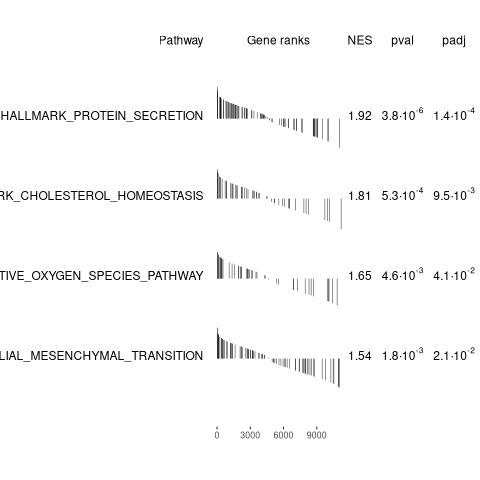

In [91]:
%%R

mainPathways <- fgsea_MOL2_significant[pathway %in% collapsedPathways$mainPathways][
                         order(-NES), pathway]
plotGseaTable(pathwaysH[mainPathways], rankings, fgsea_MOL2_significant, 
              gseaParam = 0.5)

In [92]:
%%R

fgseaResTidy <- fgsea_res %>%
  as_tibble() %>%
  arrange(desc(NES))

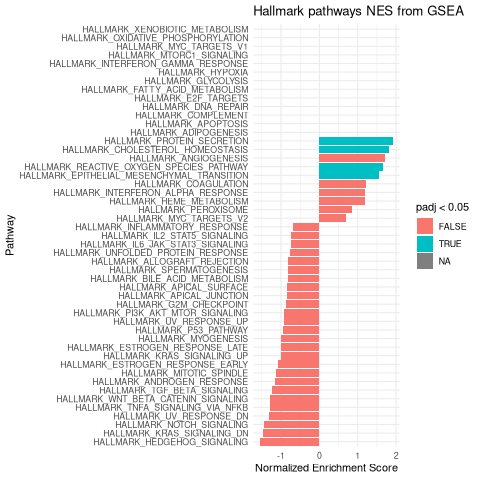

In [93]:
%%R

ggplot(fgseaResTidy, aes(reorder(pathway, NES), NES)) +
  geom_col(aes(fill=padj<0.05)) +
  coord_flip() +
  labs(x="Pathway", y="Normalized Enrichment Score",
       title="Hallmark pathways NES from GSEA") + 
  theme_minimal()


#https://stephenturner.github.io/deseq-to-fgsea/#using_the_fgsea_package

In [94]:
%%R

# Subset significant results
fgseaResSignificant <- fgseaResTidy[fgseaResTidy$padj < 0.05, ]

# Select columns to display and sort by padj
fgseaResSignificant <- fgseaResSignificant[, c("pathway", "padj", "NES", "size")]
fgseaResSignificant <- fgseaResSignificant[order(fgseaResSignificant$padj), ]

# Print the table
head(fgseaResSignificant)

# A tibble: 6 × 4
  pathway                                         padj   NES  size
  <chr>                                          <dbl> <dbl> <int>
1 HALLMARK_PROTEIN_SECRETION                  0.000136  1.92    88
2 HALLMARK_CHOLESTEROL_HOMEOSTASIS            0.00952   1.81    50
3 HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION  0.0210    1.54    81
4 HALLMARK_REACTIVE_OXYGEN_SPECIES_PATHWAY    0.0414    1.65    45
5 <NA>                                       NA        NA       NA
6 <NA>                                       NA        NA       NA


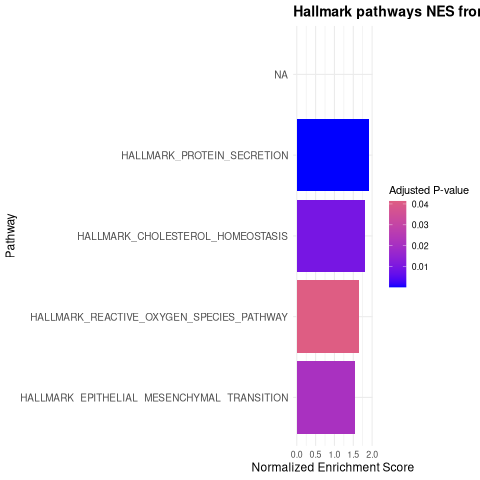

In [95]:
%%R

# Create the ggplot with a color scale for padj
ggplot(fgseaResSignificant, aes(reorder(pathway, NES), NES)) +
  geom_col(aes(fill = padj)) +
  coord_flip() +
  scale_fill_gradient(low = "#0000FF", high = "#de5d83", na.value = "black", name = "Adjusted P-value") +
  labs(x = "Pathway", y = "Normalized Enrichment Score",
       title = "Hallmark pathways NES from GSEA") +
  theme_minimal() +
  theme(
    axis.text.y = element_text(size = 10),
    axis.title = element_text(size = 12),
    plot.title = element_text(size = 14, face = "bold")
  )

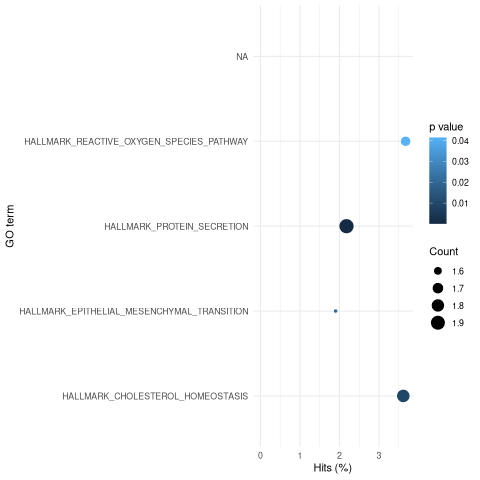

In [96]:
%%R

# Calculate hits percentage (if 'numDEInCat' and 'numInCat' equivalent are 'NES' and 'size')
fgseaResSignificant <- fgseaResSignificant %>%
  mutate(hitsPerc = NES * 100 / size)

# Ensure the columns 'padj' and 'NES' are present for the plot
fgseaResSignificant <- fgseaResSignificant %>%
  rename(term = pathway, over_represented_pvalue = padj, numDEInCat = NES)

# Create the plot
ggplot(fgseaResSignificant, aes(x = hitsPerc, y = term, colour = over_represented_pvalue, size = numDEInCat)) +
  geom_point() +
  expand_limits(x = 0) +
  labs(x = "Hits (%)", y = "GO term", colour = "p value", size = "Count") +
  theme_minimal()

#https://bioinformatics-core-shared-training.github.io/cruk-summer-school-2018/RNASeq2018/html/06_Gene_set_testing.nb.html

In [97]:
%%R

# Subset significant results
fgseaResSignificant <- fgseaResTidy[fgseaResTidy$padj < 0.05, ]

# Select columns to display and sort by padj
fgseaResSignificant <- fgseaResSignificant[, c("pathway", "padj", "NES", "size")]
fgseaResSignificant <- fgseaResSignificant[order(fgseaResSignificant$padj), ]

# Print the table
head(fgseaResSignificant)

# A tibble: 6 × 4
  pathway                                         padj   NES  size
  <chr>                                          <dbl> <dbl> <int>
1 HALLMARK_PROTEIN_SECRETION                  0.000136  1.92    88
2 HALLMARK_CHOLESTEROL_HOMEOSTASIS            0.00952   1.81    50
3 HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION  0.0210    1.54    81
4 HALLMARK_REACTIVE_OXYGEN_SPECIES_PATHWAY    0.0414    1.65    45
5 <NA>                                       NA        NA       NA
6 <NA>                                       NA        NA       NA


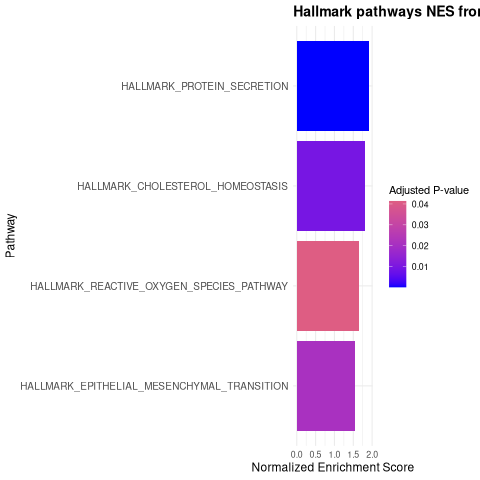

In [98]:
%%R

# Filter fgseaResSignificant to include only the main pathways from collapsedPathways
filtered_fgseaResSignificant <- fgseaResSignificant %>%
  filter(pathway %in% collapsedPathways$mainPathways)

# Create the ggplot with a color scale for padj
ggplot(filtered_fgseaResSignificant, aes(reorder(pathway, NES), NES)) +
  geom_col(aes(fill = padj)) +
  coord_flip() +
  scale_fill_gradient(low = "#0000FF", high = "#de5d83", na.value = "black", name = "Adjusted P-value") +
  labs(x = "Pathway", y = "Normalized Enrichment Score",
       title = "Hallmark pathways NES from GSEA") +
  theme_minimal() +
  theme(
    axis.text.y = element_text(size = 10),
    axis.title = element_text(size = 12),
    plot.title = element_text(size = 14, face = "bold")
  )


In [99]:
%%R

# Remove "HALLMARK_" prefix from the 'pathway' column
filtered_fgseaResSignificant$pathway <- gsub("^HALLMARK_", "", filtered_fgseaResSignificant$pathway)

# View the updated heatmap_df
head(filtered_fgseaResSignificant)

# A tibble: 4 × 4
  pathway                               padj   NES  size
  <chr>                                <dbl> <dbl> <int>
1 PROTEIN_SECRETION                 0.000136  1.92    88
2 CHOLESTEROL_HOMEOSTASIS           0.00952   1.81    50
3 EPITHELIAL_MESENCHYMAL_TRANSITION 0.0210    1.54    81
4 REACTIVE_OXYGEN_SPECIES_PATHWAY   0.0414    1.65    45


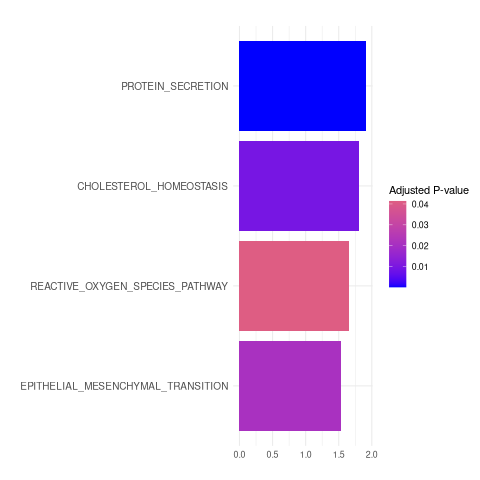

In [100]:
%%R

# Create the ggplot
plot <- ggplot(filtered_fgseaResSignificant, aes(reorder(pathway, NES), NES)) +
  geom_col(aes(fill = padj)) +
  coord_flip() +
  scale_fill_gradient(low = "#0000FF", high = "#de5d83", na.value = "black", name = "Adjusted P-value") +
  labs(x = "", y = "",
       title = "") +
  theme_minimal() +
  theme(
    axis.text.y = element_text(size = 10),
    axis.title = element_text(size = 12),
    plot.title = element_text(size = 14, face = "bold")
  )

# Save the plot as a high-resolution PNG file
#ggsave("./figures/GSEA/LPC_demyel_DAM_hallmark_pathways_NES_GSEA.png", plot = plot, dpi = 300, width = 10, height = 8)

print(plot)

In [101]:
%%R
unique(fgsea_MOL2_significant$pathway)

 [1] "HALLMARK_ANGIOGENESIS"                     
 [2] "HALLMARK_CHOLESTEROL_HOMEOSTASIS"          
 [3] "HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION"
 [4] "HALLMARK_HEDGEHOG_SIGNALING"               
 [5] "HALLMARK_HEME_METABOLISM"                  
 [6] "HALLMARK_KRAS_SIGNALING_DN"                
 [7] "HALLMARK_PROTEIN_SECRETION"                
 [8] "HALLMARK_REACTIVE_OXYGEN_SPECIES_PATHWAY"  
 [9] "HALLMARK_TNFA_SIGNALING_VIA_NFKB"          
[10] "HALLMARK_UV_RESPONSE_DN"                   


In [102]:
%%R

# Define the pathway of interest
pathway_of_interest <- "HALLMARK_CHOLESTEROL_HOMEOSTASIS"

# Subset the data to get the row with the specified pathway
selected_row <- fgsea_MOL2_significant[fgsea_MOL2_significant$pathway == pathway_of_interest, ]

# Extract the leadingEdge column as a list of gene symbols
leading_edge_genes <- unlist(selected_row$leadingEdge)

# Print the list of genes
print(leading_edge_genes)

 [1] "Gusb"   "Lpl"    "Anxa5"  "Lgals3" "Fabp5"  "Cxcl16" "Dhcr7"  "Cd9"   
 [9] "Ethe1"  "Pmvk"   "Antxr2" "Lgmn"   "Jag1"   "Plscr1" "Pdk3"   "Tmem97"
[17] "Nfil3"  "Alcam" 


In [103]:
%%R

# Define the pathway of interest
pathway_of_interest <- "HALLMARK_PROTEIN_SECRETION"

# Subset the data to get the row with the specified pathway
selected_row <- fgsea_MOL2_significant[fgsea_MOL2_significant$pathway == pathway_of_interest, ]

# Extract the leadingEdge column as a list of gene symbols
leading_edge_genes <- unlist(selected_row$leadingEdge)

# Print the list of genes
print(leading_edge_genes)

 [1] "Cd63"   "Tpd52"  "Tmed10" "Abca1"  "Ap2s1"  "Ap3s1"  "Igf2r"  "Galc"  
 [9] "Pam"    "Bet1"   "Rab9"   "Ica1"   "Sgms1"  "Clta"   "Stx12"  "Ap2m1" 
[17] "Gnas"   "Ppt1"   "Vamp7"  "Bnip3"  "Tmed2"  "Gla"    "Ctsc"   "Cope"  
[25] "Ergic3" "Vps45"  "Tsg101" "Rer1"   "Napa"   "Stx7"   "Stam"   "Sod1"  
[33] "Clcn3" 


In [104]:
%%R

# Define the pathway of interest
pathway_of_interest <- "HALLMARK_NOTCH_SIGNALING"

# Subset the data to get the row with the specified pathway
selected_row <- fgsea_MOL2_significant[fgsea_MOL2_significant$pathway == pathway_of_interest, ]

# Extract the leadingEdge column as a list of gene symbols
leading_edge_genes <- unlist(selected_row$leadingEdge)

# Print the list of genes
print(leading_edge_genes)

NULL


In [105]:
%%R

# Define the pathway of interest
pathway_of_interest <- "HALLMARK_COAGULATION"

# Subset the data to get the row with the specified pathway
selected_row <- fgsea_MOL2_significant[fgsea_MOL2_significant$pathway == pathway_of_interest, ]

# Extract the leadingEdge column as a list of gene symbols
leading_edge_genes <- unlist(selected_row$leadingEdge)

# Print the list of genes
print(leading_edge_genes)

NULL


In [106]:
%%R

# Define the pathway of interest
pathway_of_interest <- "HALLMARK_INFLAMMATORY_RESPONSE"

# Subset the data to get the row with the specified pathway
selected_row <- fgsea_MOL2_significant[fgsea_MOL2_significant$pathway == pathway_of_interest, ]

# Extract the leadingEdge column as a list of gene symbols
leading_edge_genes <- unlist(selected_row$leadingEdge)

# Print the list of genes
print(leading_edge_genes)

NULL


In [ ]:
%%R

# Define the pathway of interest
pathway_of_interest <- "HALLMARK_INTERFERON_ALPHA_RESPONSE"

# Subset the data to get the row with the specified pathway
selected_row <- fgsea_MOL2_significant[fgsea_MOL2_significant$pathway == pathway_of_interest, ]

# Extract the leadingEdge column as a list of gene symbols
leading_edge_genes <- unlist(selected_row$leadingEdge)

# Print the list of genes
print(leading_edge_genes)

In [ ]:
%%R

# Define the pathway of interest
pathway_of_interest <- "HALLMARK_KRAS_SIGNALING_DN"

# Subset the data to get the row with the specified pathway
selected_row <- fgsea_MOL2_significant[fgsea_MOL2_significant$pathway == pathway_of_interest, ]

# Extract the leadingEdge column as a list of gene symbols
leading_edge_genes <- unlist(selected_row$leadingEdge)

# Print the list of genes
print(leading_edge_genes)

In [107]:
%%R

fgsea_MOL2_significant <- as.data.frame(fgsea_MOL2_significant)

In [108]:
%%R
library(data.table)
fwrite(fgsea_MOL2_significant, file = "./files/filtered_fgseaResSignificant_LPC_demyel_allgene.csv")

# LPC_remyel_DAMs

In [109]:
%%R

# Replace the file path with the actual path if the file is not in the current directory
df <- read.csv("./files/LPC_remyel_MG_bulk_voom_wqw.csv")
head(df)  # Display the first few rows of the data frame to confirm it's loaded correctly

           gene     logFC   AveExpr         t      P.Value    adj.P.Val
1          Apoe  6.293966 13.478233  38.19939 2.709751e-10 2.891304e-06
2          Lyz2  3.772911 10.692487  21.12425 2.876369e-08 1.534543e-04
3       Slc24a3 -2.776927  6.084104 -16.56360 1.911877e-07 5.301253e-04
4        Plxna4 -2.626495  6.496358 -15.93524 2.578972e-07 5.301253e-04
5 8030442B05Rik -2.948840  5.391611 -15.32104 3.493621e-07 5.301253e-04
6          Sox4 -3.136640  5.740063 -15.11783 3.872500e-07 5.301253e-04
          B
1 12.873942
2  9.604574
3  7.908587
4  7.663755
5  7.299123
6  7.253307


In [110]:
%%R

dim(df)

[1] 10670     7


In [111]:
%%R

my_genes <- df$gene
head(my_genes)

[1] "Apoe"          "Lyz2"          "Slc24a3"       "Plxna4"       
[5] "8030442B05Rik" "Sox4"         


In [112]:
%%R
# Check column names in the dataframe
colnames(df)

[1] "gene"      "logFC"     "AveExpr"   "t"         "P.Value"   "adj.P.Val"
[7] "B"        


In [113]:
%%R

# Compute ranking score using all genes
df$ranking_score <- -log10(df$P.Value) * sign(df$logFC)

# Assign gene names
rankings <- df$ranking_score
names(rankings) <- df$gene

# Sort rankings
rankings <- sort(rankings, decreasing = TRUE)

In [114]:
%%R

# Ensure the length of the gene column matches the length of rankings
length(df$gene) == length(rankings)

[1] TRUE


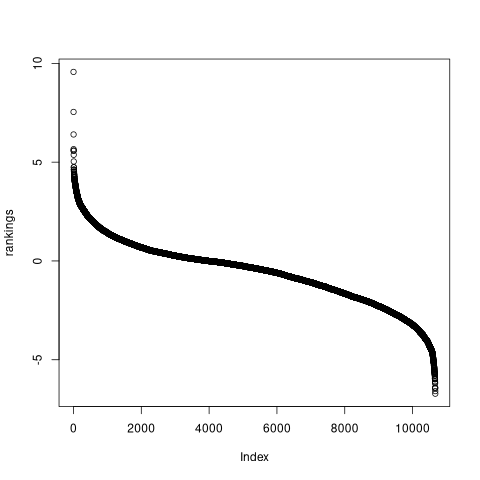

In [115]:
%%R

plot(rankings)

In [116]:
%%R

max(rankings)

[1] 9.567071


In [117]:
%%R

min(rankings)

[1] -6.71854


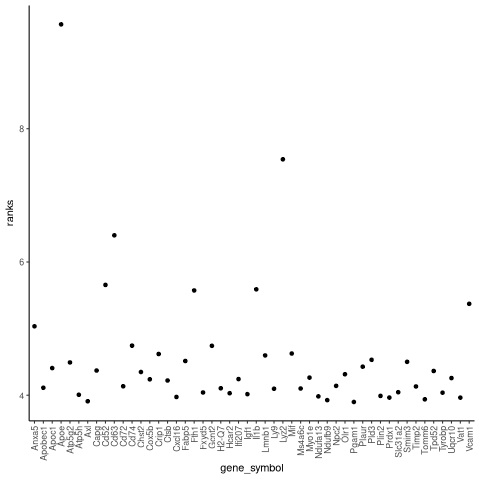

In [118]:
%%R

ggplot(data.frame(gene_symbol = names(rankings)[1:50], ranks = rankings[1:50]), aes(gene_symbol, ranks)) + 
    geom_point() +
    theme_classic() + 
    theme(axis.text.x = element_text(angle = 90, vjust = 0.5, hjust=1))

# Figure out how to set up gene lists

In [119]:
%%R
fgsea_res <- fgsea(pathways = pathwaysH, 
                  stats    = rankings,
                  scoreType = 'std',
                  minSize  = 15,
                  maxSize  = 500)

In addition: Warning message:
In fgseaMultilevel(pathways = pathways, stats = stats, minSize = minSize,  :
  There were 6 pathways for which P-values were not calculated properly due to unbalanced (positive and negative) gene-level statistic values. For such pathways pval, padj, NES, log2err are set to NA. You can try to increase the value of the argument nPermSimple (for example set it nPermSimple = 10000)


In [120]:
%%R
fgsea_res

                                       pathway         pval         padj
                                        <char>        <num>        <num>
 1:                      HALLMARK_ADIPOGENESIS           NA           NA
 2:               HALLMARK_ALLOGRAFT_REJECTION           NA           NA
 3:                 HALLMARK_ANDROGEN_RESPONSE 3.020833e-02 6.041667e-02
 4:                   HALLMARK_APICAL_JUNCTION 3.196300e-01 4.474820e-01
 5:                    HALLMARK_APICAL_SURFACE 2.959184e-01 4.285714e-01
 6:                         HALLMARK_APOPTOSIS 1.565421e-02 3.460404e-02
 7:              HALLMARK_BILE_ACID_METABOLISM 7.515924e-01 8.094072e-01
 8:           HALLMARK_CHOLESTEROL_HOMEOSTASIS 3.031673e-07 1.273302e-05
 9:                       HALLMARK_COAGULATION 5.290523e-04 2.916726e-03
10:                        HALLMARK_COMPLEMENT 1.503240e-05 1.945827e-04
11:                        HALLMARK_DNA_REPAIR 2.198124e-03 6.594373e-03
12:                       HALLMARK_E2F_TARGETS 7.32

In [121]:
%%R

dim(fgsea_res)

[1] 48  8


In [122]:
%%R

library(data.table)
fwrite(fgsea_res, file = "./files/fgsea_LPC_remyel_DAMs_allgenes.csv")

In [123]:
%%R

# Filter for significant results with padj < 0.05
fgsea_MOL4_significant <- fgsea_res %>% filter(padj < 0.1)
dim(fgsea_MOL4_significant)

[1] 22  8


In [124]:
%%R

head(fgsea_MOL4_significant)

                            pathway         pval         padj   log2err
                             <char>        <num>        <num>     <num>
1:       HALLMARK_ANDROGEN_RESPONSE 3.020833e-02 6.041667e-02 0.2663507
2:               HALLMARK_APOPTOSIS 1.565421e-02 3.460404e-02 0.3524879
3: HALLMARK_CHOLESTEROL_HOMEOSTASIS 3.031673e-07 1.273302e-05 0.6749629
4:             HALLMARK_COAGULATION 5.290523e-04 2.916726e-03 0.4772708
5:              HALLMARK_COMPLEMENT 1.503240e-05 1.945827e-04 0.5933255
6:              HALLMARK_DNA_REPAIR 2.198124e-03 6.594373e-03 0.4317077
           ES       NES  size                               leadingEdge
        <num>     <num> <int>                                    <list>
1: -0.4253229 -1.332395    77    Hpgd,Ccnd1,Lifr,Inpp4b,Maf,Slc38a2,...
2:  0.2604575  1.210711   113    Il1b,Timp2,Lgals3,Cd14,Sod2,Pmaip1,...
3:  0.5750015  2.346924    49 Anxa5,Fabp5,Plaur,Cxcl16,Lgals3,Nfil3,...
4:  0.3978502  1.712795    62         Apoc1,Olr1,Ctsb,Apoc2,C3,M

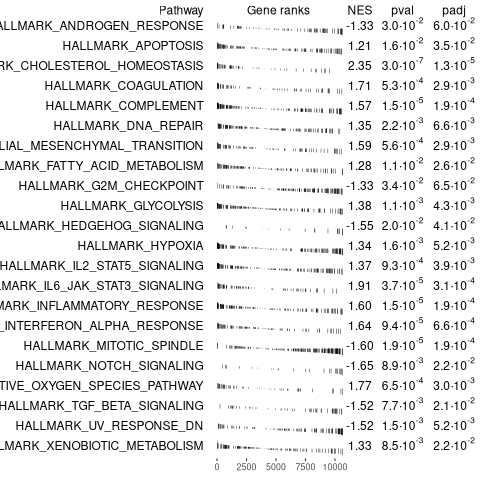

In [125]:
%%R

plotGseaTable(pathwaysH[fgsea_MOL4_significant$pathway], 
              rankings, 
              fgsea_MOL4_significant, 
              gseaParam = 0.5)

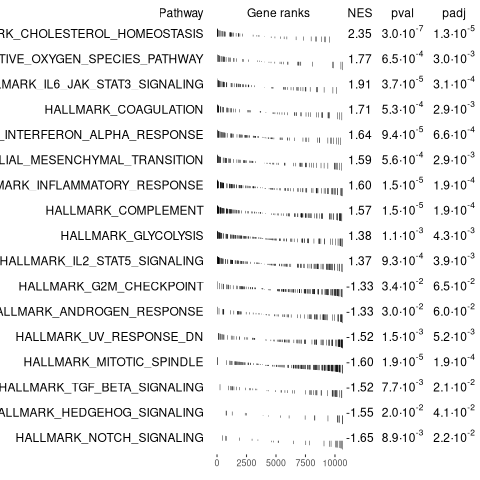

In [126]:
%%R

topUp <- fgsea_MOL4_significant %>% 
    filter(ES > 0) %>% 
    top_n(10, wt=-padj)

topDown <- fgsea_MOL4_significant %>% 
    filter(ES < 0) %>% 
    top_n(10, wt=-padj)

topPathways <- bind_rows(topUp, topDown) %>% 
    arrange(-ES)

plotGseaTable(pathwaysH[topPathways$pathway], 
              rankings, 
              fgsea_MOL4_significant, 
              gseaParam = 0.5)

In [127]:
%%R

collapsedPathways <- collapsePathways(fgsea_MOL4_significant[order(pval)][padj < 0.05], 
                                      pathwaysH, rankings)

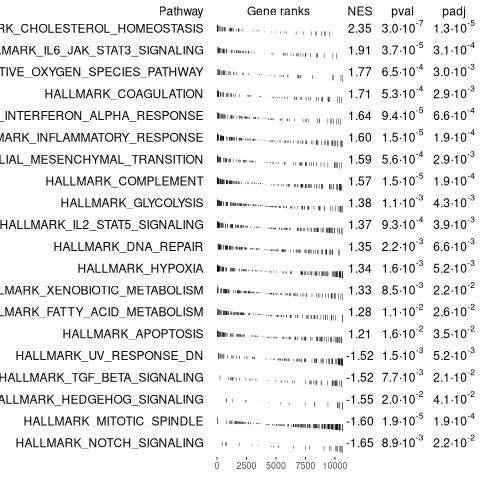

In [128]:
%%R

mainPathways <- fgsea_MOL4_significant[pathway %in% collapsedPathways$mainPathways][
                         order(-NES), pathway]
plotGseaTable(pathwaysH[mainPathways], rankings, fgsea_MOL4_significant, 
              gseaParam = 0.5)

In [129]:
%%R

fgseaResTidy <- fgsea_res %>%
  as_tibble() %>%
  arrange(desc(NES))

In [130]:
%%R

# Subset significant results
fgseaResSignificant <- fgseaResTidy[fgseaResTidy$padj < 0.05, ]

# Select columns to display and sort by padj
fgseaResSignificant <- fgseaResSignificant[, c("pathway", "padj", "NES", "size")]
fgseaResSignificant <- fgseaResSignificant[order(fgseaResSignificant$padj), ]

# Print the table
head(fgseaResSignificant)

# A tibble: 6 × 4
  pathway                                 padj   NES  size
  <chr>                                  <dbl> <dbl> <int>
1 HALLMARK_CHOLESTEROL_HOMEOSTASIS   0.0000127  2.35    49
2 HALLMARK_INFLAMMATORY_RESPONSE     0.000195   1.60   124
3 HALLMARK_COMPLEMENT                0.000195   1.57   129
4 HALLMARK_MITOTIC_SPINDLE           0.000195  -1.60   152
5 HALLMARK_IL6_JAK_STAT3_SIGNALING   0.000309   1.91    66
6 HALLMARK_INTERFERON_ALPHA_RESPONSE 0.000661   1.64    88


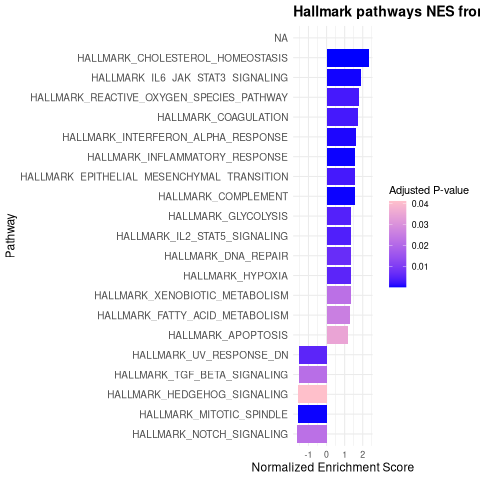

In [131]:
%%R

# Create the ggplot with a color scale for padj
ggplot(fgseaResSignificant, aes(reorder(pathway, NES), NES)) +
  geom_col(aes(fill = padj)) +
  coord_flip() +
  scale_fill_gradient(low = "blue", high = "pink", na.value = "black", name = "Adjusted P-value") +
  labs(x = "Pathway", y = "Normalized Enrichment Score",
       title = "Hallmark pathways NES from GSEA") +
  theme_minimal() +
  theme(
    axis.text.y = element_text(size = 10),
    axis.title = element_text(size = 12),
    plot.title = element_text(size = 14, face = "bold")
  )

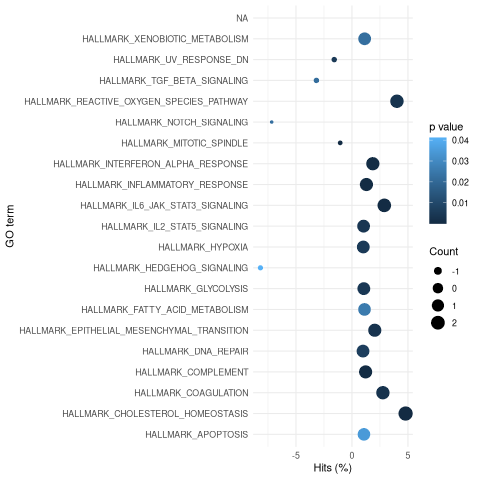

In [132]:
%%R

# Calculate hits percentage (if 'numDEInCat' and 'numInCat' equivalent are 'NES' and 'size')
fgseaResSignificant <- fgseaResSignificant %>%
  mutate(hitsPerc = NES * 100 / size)

# Ensure the columns 'padj' and 'NES' are present for the plot
fgseaResSignificant <- fgseaResSignificant %>%
  rename(term = pathway, over_represented_pvalue = padj, numDEInCat = NES)

# Create the plot
ggplot(fgseaResSignificant, aes(x = hitsPerc, y = term, colour = over_represented_pvalue, size = numDEInCat)) +
  geom_point() +
  expand_limits(x = 0) +
  labs(x = "Hits (%)", y = "GO term", colour = "p value", size = "Count") +
  theme_minimal()

#https://bioinformatics-core-shared-training.github.io/cruk-summer-school-2018/RNASeq2018/html/06_Gene_set_testing.nb.html

In [133]:
%%R

# Subset significant results
fgseaResSignificant <- fgseaResTidy[fgseaResTidy$padj < 0.05, ]

# Select columns to display and sort by padj
fgseaResSignificant <- fgseaResSignificant[, c("pathway", "padj", "NES", "size")]
fgseaResSignificant <- fgseaResSignificant[order(fgseaResSignificant$padj), ]

# Print the table
head(fgseaResSignificant)

# A tibble: 6 × 4
  pathway                                 padj   NES  size
  <chr>                                  <dbl> <dbl> <int>
1 HALLMARK_CHOLESTEROL_HOMEOSTASIS   0.0000127  2.35    49
2 HALLMARK_INFLAMMATORY_RESPONSE     0.000195   1.60   124
3 HALLMARK_COMPLEMENT                0.000195   1.57   129
4 HALLMARK_MITOTIC_SPINDLE           0.000195  -1.60   152
5 HALLMARK_IL6_JAK_STAT3_SIGNALING   0.000309   1.91    66
6 HALLMARK_INTERFERON_ALPHA_RESPONSE 0.000661   1.64    88


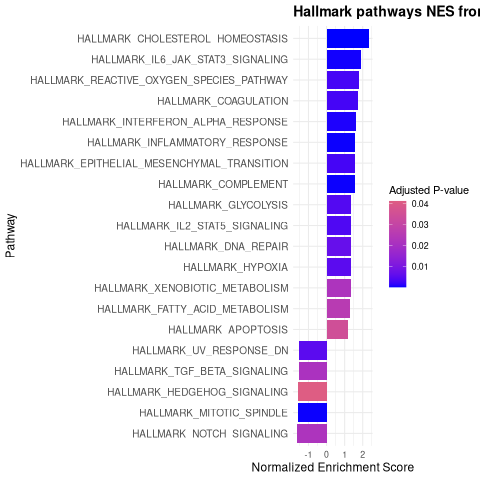

In [134]:
%%R

# Filter fgseaResSignificant to include only the main pathways from collapsedPathways
filtered_fgseaResSignificant <- fgseaResSignificant %>%
  filter(pathway %in% collapsedPathways$mainPathways)

# Create the ggplot with a color scale for padj
ggplot(filtered_fgseaResSignificant, aes(reorder(pathway, NES), NES)) +
  geom_col(aes(fill = padj)) +
  coord_flip() +
  scale_fill_gradient(low = "#0000FF", high = "#de5d83", na.value = "black", name = "Adjusted P-value") +
  labs(x = "Pathway", y = "Normalized Enrichment Score",
       title = "Hallmark pathways NES from GSEA") +
  theme_minimal() +
  theme(
    axis.text.y = element_text(size = 10),
    axis.title = element_text(size = 12),
    plot.title = element_text(size = 14, face = "bold")
  )


In [135]:
%%R

# Remove "HALLMARK_" prefix from the 'pathway' column
filtered_fgseaResSignificant$pathway <- gsub("^HALLMARK_", "", filtered_fgseaResSignificant$pathway)

# View the updated heatmap_df
head(filtered_fgseaResSignificant)

# A tibble: 6 × 4
  pathway                        padj   NES  size
  <chr>                         <dbl> <dbl> <int>
1 CHOLESTEROL_HOMEOSTASIS   0.0000127  2.35    49
2 INFLAMMATORY_RESPONSE     0.000195   1.60   124
3 COMPLEMENT                0.000195   1.57   129
4 MITOTIC_SPINDLE           0.000195  -1.60   152
5 IL6_JAK_STAT3_SIGNALING   0.000309   1.91    66
6 INTERFERON_ALPHA_RESPONSE 0.000661   1.64    88


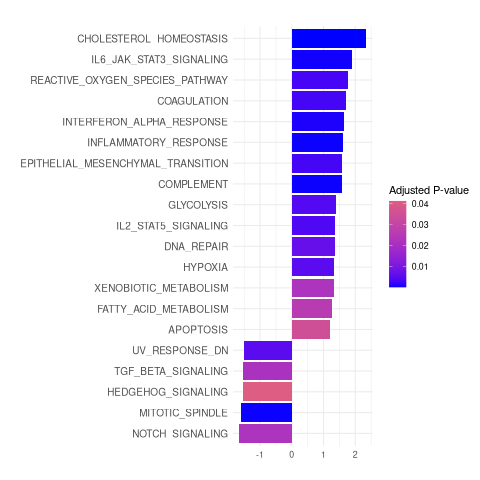

In [136]:
%%R

# Create the ggplot
plot <- ggplot(filtered_fgseaResSignificant, aes(reorder(pathway, NES), NES)) +
  geom_col(aes(fill = padj)) +
  coord_flip() +
  scale_fill_gradient(low = "#0000FF", high = "#de5d83", na.value = "black", name = "Adjusted P-value") +
  labs(x = "", y = "",
       title = "") +
  theme_minimal() +
  theme(
    axis.text.y = element_text(size = 10),
    axis.title = element_text(size = 12),
    plot.title = element_text(size = 14, face = "bold")
  )

# Save the plot as a high-resolution PNG file
#ggsave("./figures/GSEA/LPC_remyel_DAM_hallmark_pathways_NES_GSEA.png", plot = plot, dpi = 300, width = 10, height = 8)

print(plot)

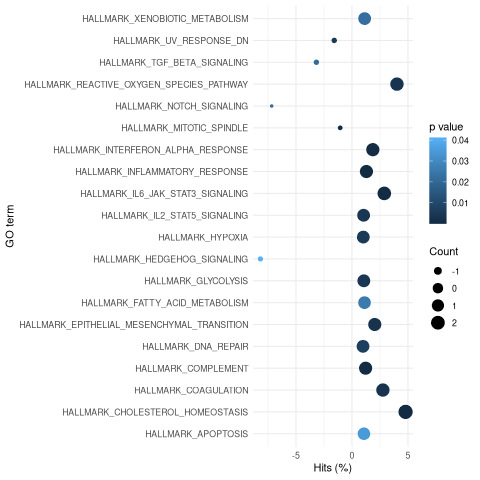

In [137]:
%%R

# Filter fgseaResSignificant to include only the main pathways from collapsedPathways
filtered_fgseaResSignificant <- fgseaResSignificant %>%
  filter(pathway %in% collapsedPathways$mainPathways)

# Calculate hits percentage
filtered_fgseaResSignificant <- filtered_fgseaResSignificant %>%
  mutate(hitsPerc = NES * 100 / size)

# Ensure the columns 'padj' and 'NES' are present for the plot
filtered_fgseaResSignificant <- filtered_fgseaResSignificant %>%
  rename(term = pathway, over_represented_pvalue = padj, numDEInCat = NES)

# Create the plot
ggplot(filtered_fgseaResSignificant, aes(x = hitsPerc, y = term, colour = over_represented_pvalue, size = numDEInCat)) +
  geom_point() +
  expand_limits(x = 0) +
  labs(x = "Hits (%)", y = "GO term", colour = "p value", size = "Count") +
  theme_minimal()


In [138]:
%%R
unique(fgsea_MOL4_significant$pathway)

 [1] "HALLMARK_ANDROGEN_RESPONSE"                
 [2] "HALLMARK_APOPTOSIS"                        
 [3] "HALLMARK_CHOLESTEROL_HOMEOSTASIS"          
 [4] "HALLMARK_COAGULATION"                      
 [5] "HALLMARK_COMPLEMENT"                       
 [6] "HALLMARK_DNA_REPAIR"                       
 [7] "HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION"
 [8] "HALLMARK_FATTY_ACID_METABOLISM"            
 [9] "HALLMARK_G2M_CHECKPOINT"                   
[10] "HALLMARK_GLYCOLYSIS"                       
[11] "HALLMARK_HEDGEHOG_SIGNALING"               
[12] "HALLMARK_HYPOXIA"                          
[13] "HALLMARK_IL2_STAT5_SIGNALING"              
[14] "HALLMARK_IL6_JAK_STAT3_SIGNALING"          
[15] "HALLMARK_INFLAMMATORY_RESPONSE"            
[16] "HALLMARK_INTERFERON_ALPHA_RESPONSE"        
[17] "HALLMARK_MITOTIC_SPINDLE"                  
[18] "HALLMARK_NOTCH_SIGNALING"                  
[19] "HALLMARK_REACTIVE_OXYGEN_SPECIES_PATHWAY"  
[20] "HALLMARK_TGF_BETA_SIGNALING"               


In [139]:
%%R

# Define the pathway of interest
pathway_of_interest <- "HALLMARK_IL6_JAK_STAT3_SIGNALING"

# Subset the data to get the row with the specified pathway
selected_row <- fgsea_MOL4_significant[fgsea_MOL4_significant$pathway == pathway_of_interest, ]

# Extract the leadingEdge column as a list of gene symbols
leading_edge_genes <- unlist(selected_row$leadingEdge)

# Print the list of genes
print(leading_edge_genes)

 [1] "Il1b"     "Cd14"     "Il3ra"    "Pim1"     "Cd9"      "Csf2ra"  
 [7] "Cd44"     "Tlr2"     "Csf1"     "Crlf2"    "Ifnar1"   "Socs3"   
[13] "Cxcl9"    "Csf2rb2"  "Il2rg"    "Cd36"     "Itga4"    "Acvrl1"  
[19] "Il10rb"   "Tnfrsf1b" "Cxcl13"   "Pik3r5"   "Ifngr2"   "Cxcl2"   
[25] "Tnfrsf1a" "Hax1"     "Stat2"    "Fas"      "Ltbr"    


In [ ]:
%%R

# Define the pathway of interest
pathway_of_interest <- "HALLMARK_IL2_STAT5_SIGNALING"

# Subset the data to get the row with the specified pathway
selected_row <- fgsea_MOL4_significant[fgsea_MOL4_significant$pathway == pathway_of_interest, ]

# Extract the leadingEdge column as a list of gene symbols
leading_edge_genes <- unlist(selected_row$leadingEdge)

# Print the list of genes
print(leading_edge_genes)

In [ ]:
%%R

# Define the pathway of interest
pathway_of_interest <- "HALLMARK_PROTEIN_SECRETION"

# Subset the data to get the row with the specified pathway
selected_row <- fgsea_MOL4_significant[fgsea_MOL4_significant$pathway == pathway_of_interest, ]

# Extract the leadingEdge column as a list of gene symbols
leading_edge_genes <- unlist(selected_row$leadingEdge)

# Print the list of genes
print(leading_edge_genes)

In [ ]:
%%R

# Define the pathway of interest
pathway_of_interest <- "HALLMARK_TNFA_SIGNALING_VIA_NFKB"

# Subset the data to get the row with the specified pathway
selected_row <- fgsea_MOL4_significant[fgsea_MOL4_significant$pathway == pathway_of_interest, ]

# Extract the leadingEdge column as a list of gene symbols
leading_edge_genes <- unlist(selected_row$leadingEdge)

# Print the list of genes
print(leading_edge_genes)

In [ ]:
%%R

# Define the pathway of interest
pathway_of_interest <- "HALLMARK_INTERFERON_GAMMA_RESPONSE"

# Subset the data to get the row with the specified pathway
selected_row <- fgsea_MOL4_significant[fgsea_MOL4_significant$pathway == pathway_of_interest, ]

# Extract the leadingEdge column as a list of gene symbols
leading_edge_genes <- unlist(selected_row$leadingEdge)

# Print the list of genes
print(leading_edge_genes)

In [ ]:
%%R

# Define the pathway of interest
pathway_of_interest <- "HALLMARK_INTERFERON_ALPHA_RESPONSE"

# Subset the data to get the row with the specified pathway
selected_row <- fgsea_MOL4_significant[fgsea_MOL4_significant$pathway == pathway_of_interest, ]

# Extract the leadingEdge column as a list of gene symbols
leading_edge_genes <- unlist(selected_row$leadingEdge)

# Print the list of genes
print(leading_edge_genes)

In [ ]:
%%R

# Define the pathway of interest
pathway_of_interest <- "HALLMARK_COAGULATION"

# Subset the data to get the row with the specified pathway
selected_row <- fgsea_MOL4_significant[fgsea_MOL4_significant$pathway == pathway_of_interest, ]

# Extract the leadingEdge column as a list of gene symbols
leading_edge_genes <- unlist(selected_row$leadingEdge)

# Print the list of genes
print(leading_edge_genes)

In [140]:
%%R

fgsea_MOL4_significant <- as.data.frame(fgsea_MOL4_significant)

In [141]:
%%R
library(data.table)
fwrite(fgsea_MOL4_significant, file = "./files/filtered_fgseaResSignificant_LPC_remyel_allgene.csv")

# Cupr_demyel_DAMs

In [142]:
%%R

# Replace the file path with the actual path if the file is not in the current directory
df <- read.csv("./files/Cupr_demyel_Mg_voom_wqw_NEW.csv")
head(df)  # Display the first few rows of the data frame to confirm it's loaded correctly

     gene     logFC   AveExpr         t      P.Value    adj.P.Val        B
1 Gm49708 -3.669051 2.3073050 -11.06653 1.383796e-07 0.0005247076 7.972017
2 Gm10406 -3.551111 1.9525861 -10.61366 2.173316e-07 0.0005247076 7.461662
3  Sema4b -3.992705 1.6282744 -10.40832 2.681064e-07 0.0005247076 7.233389
4   Adcy8 -4.637577 0.7441331 -10.33925 2.879436e-07 0.0005247076 7.031894
5 A3galt2 -3.225712 1.0910237 -10.26464 3.111621e-07 0.0005247076 7.091532
6   Nrarp -3.772757 1.2981518 -10.24259 3.184044e-07 0.0005247076 7.075280


In [143]:
%%R

dim(df)

[1] 11057     7


In [144]:
%%R

my_genes <- df$gene
head(my_genes)

[1] "Gm49708" "Gm10406" "Sema4b"  "Adcy8"   "A3galt2" "Nrarp"  


In [145]:
%%R
# Check column names in the dataframe
colnames(df)

[1] "gene"      "logFC"     "AveExpr"   "t"         "P.Value"   "adj.P.Val"
[7] "B"        


In [146]:
%%R

# Compute ranking score using all genes
df$ranking_score <- -log10(df$P.Value) * sign(df$logFC)

# Assign gene names
rankings <- df$ranking_score
names(rankings) <- df$gene

# Sort rankings
rankings <- sort(rankings, decreasing = TRUE)

In [147]:
%%R

# Ensure the length of the gene column matches the length of rankings
length(df$gene) == length(rankings)

[1] TRUE


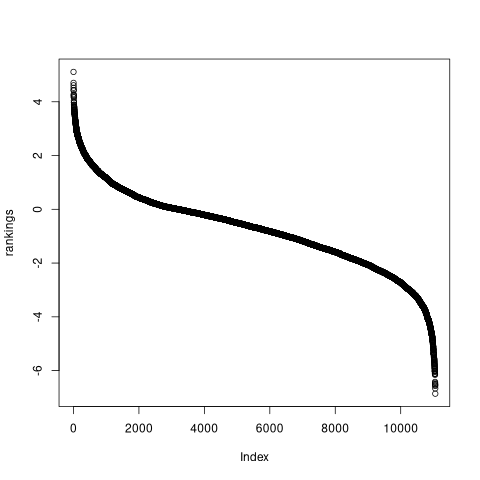

In [148]:
%%R

plot(rankings)

In [149]:
%%R

max(rankings)

[1] 5.111362


In [150]:
%%R

min(rankings)

[1] -6.858928


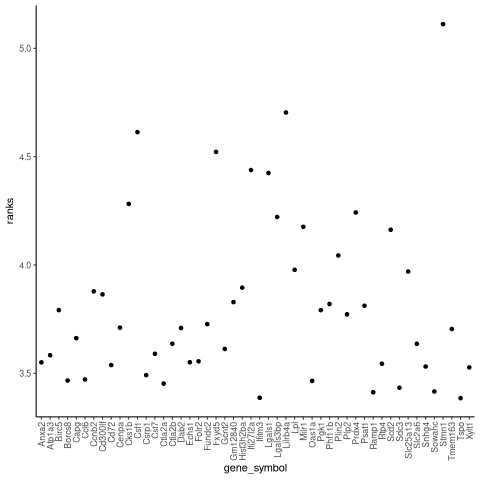

In [151]:
%%R

ggplot(data.frame(gene_symbol = names(rankings)[1:50], ranks = rankings[1:50]), aes(gene_symbol, ranks)) + 
    geom_point() +
    theme_classic() + 
    theme(axis.text.x = element_text(angle = 90, vjust = 0.5, hjust=1))

# Figure out how to set up gene lists

In [152]:
%%R
fgsea_res <- fgsea(pathways = pathwaysH, 
                  stats    = rankings,
                  scoreType = 'std',
                  minSize  = 15,
                  maxSize  = 500)

In addition: Warning messages:
1: In fgseaMultilevel(pathways = pathways, stats = stats, minSize = minSize,  :
  There were 14 pathways for which P-values were not calculated properly due to unbalanced (positive and negative) gene-level statistic values. For such pathways pval, padj, NES, log2err are set to NA. You can try to increase the value of the argument nPermSimple (for example set it nPermSimple = 10000)
2: In fgseaMultilevel(pathways = pathways, stats = stats, minSize = minSize,  :
  For some of the pathways the P-values were likely overestimated. For such pathways log2err is set to NA.


In [153]:
%%R
fgsea_res

                                       pathway         pval         padj
                                        <char>        <num>        <num>
 1:                      HALLMARK_ADIPOGENESIS           NA           NA
 2:               HALLMARK_ALLOGRAFT_REJECTION 6.746988e-01 1.000000e+00
 3:                 HALLMARK_ANDROGEN_RESPONSE 9.247202e-01 1.000000e+00
 4:                      HALLMARK_ANGIOGENESIS 7.737123e-04 4.513322e-03
 5:                   HALLMARK_APICAL_JUNCTION 9.290780e-01 1.000000e+00
 6:                    HALLMARK_APICAL_SURFACE 2.796610e-01 8.494236e-01
 7:                         HALLMARK_APOPTOSIS           NA           NA
 8:              HALLMARK_BILE_ACID_METABOLISM 3.835198e-01 1.000000e+00
 9:           HALLMARK_CHOLESTEROL_HOMEOSTASIS 1.546343e-07 1.804067e-06
10:                       HALLMARK_COAGULATION 4.217881e-03 2.108941e-02
11:                        HALLMARK_COMPLEMENT           NA           NA
12:                        HALLMARK_DNA_REPAIR 9.96

In [154]:
%%R

dim(fgsea_res)

[1] 49  8


In [155]:
%%R

library(data.table)
fwrite(fgsea_res, file = "./files/fgsea_Cupr_demyel_DAMs_allgenes.csv")

In [156]:
%%R

# Filter for significant results with padj < 0.05
fgsea_MOL4_significant <- fgsea_res %>% filter(padj < 0.1)
dim(fgsea_MOL4_significant)

[1] 7 8


In [157]:
%%R

head(fgsea_MOL4_significant)

                                      pathway         pval         padj
                                       <char>        <num>        <num>
1:                      HALLMARK_ANGIOGENESIS 7.737123e-04 4.513322e-03
2:           HALLMARK_CHOLESTEROL_HOMEOSTASIS 1.546343e-07 1.804067e-06
3:                       HALLMARK_COAGULATION 4.217881e-03 2.108941e-02
4: HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION 4.689479e-09 8.206588e-08
5:           HALLMARK_IL6_JAK_STAT3_SIGNALING 1.927656e-04 1.349359e-03
6:         HALLMARK_INTERFERON_ALPHA_RESPONSE 2.203834e-13 7.713418e-12
     log2err        ES      NES  size                              leadingEdge
       <num>     <num>    <num> <int>                                   <list>
1: 0.4772708 0.6701397 2.252451    15      Lpl,Spp1,Lrpap1,Pf4,Ccnd2,Pdgfa,...
2: 0.6901325 0.5313225 2.443309    51   Scd2,Lpl,Anxa5,Fabp5,Cxcl16,Lgals3,...
3: 0.4070179 0.3081736 1.492476    68       Csrp1,Fn1,Ctsb,Gng12,Pf4,Apoc2,...
4: 0.7614608 0.4726702 2.3460

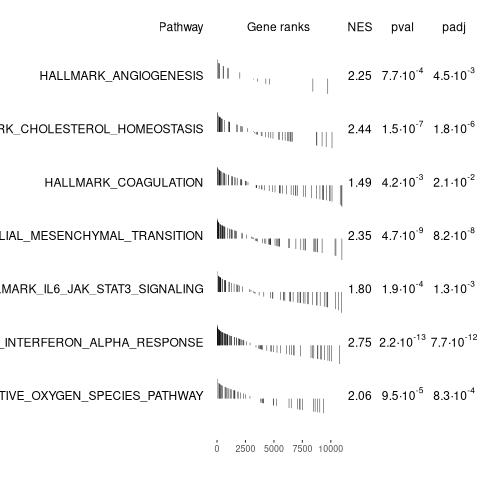

In [158]:
%%R

plotGseaTable(pathwaysH[fgsea_MOL4_significant$pathway], 
              rankings, 
              fgsea_MOL4_significant, 
              gseaParam = 0.5)

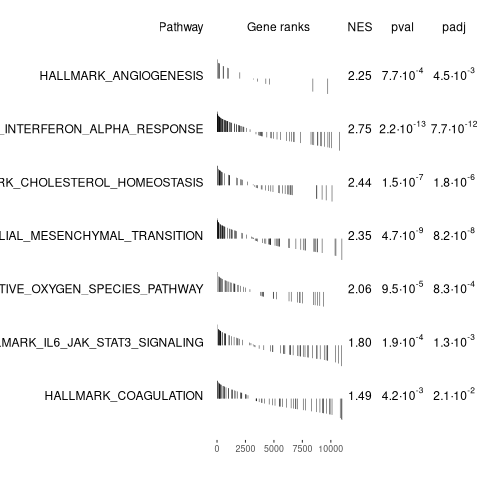

In [159]:
%%R

topUp <- fgsea_MOL4_significant %>% 
    filter(ES > 0) %>% 
    top_n(10, wt=-padj)

topDown <- fgsea_MOL4_significant %>% 
    filter(ES < 0) %>% 
    top_n(10, wt=-padj)

topPathways <- bind_rows(topUp, topDown) %>% 
    arrange(-ES)

plotGseaTable(pathwaysH[topPathways$pathway], 
              rankings, 
              fgsea_MOL4_significant, 
              gseaParam = 0.5)

In [160]:
%%R

collapsedPathways <- collapsePathways(fgsea_MOL4_significant[order(pval)][padj < 0.05], 
                                      pathwaysH, rankings)

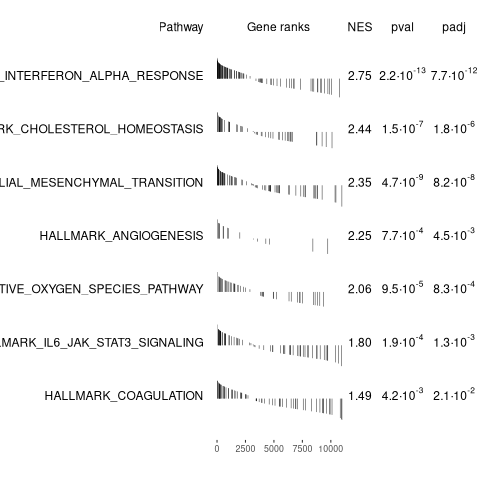

In [161]:
%%R

mainPathways <- fgsea_MOL4_significant[pathway %in% collapsedPathways$mainPathways][
                         order(-NES), pathway]
plotGseaTable(pathwaysH[mainPathways], rankings, fgsea_MOL4_significant, 
              gseaParam = 0.5)

In [162]:
%%R

fgseaResTidy <- fgsea_res %>%
  as_tibble() %>%
  arrange(desc(NES))

In [163]:
%%R

# Subset significant results
fgseaResSignificant <- fgseaResTidy[fgseaResTidy$padj < 0.05, ]

# Select columns to display and sort by padj
fgseaResSignificant <- fgseaResSignificant[, c("pathway", "padj", "NES", "size")]
fgseaResSignificant <- fgseaResSignificant[order(fgseaResSignificant$padj), ]

# Print the table
head(fgseaResSignificant)

# A tibble: 6 × 4
  pathway                                        padj   NES  size
  <chr>                                         <dbl> <dbl> <int>
1 HALLMARK_INTERFERON_ALPHA_RESPONSE         7.71e-12  2.75    87
2 HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION 8.21e- 8  2.35    76
3 HALLMARK_CHOLESTEROL_HOMEOSTASIS           1.80e- 6  2.44    51
4 HALLMARK_REACTIVE_OXYGEN_SPECIES_PATHWAY   8.31e- 4  2.06    44
5 HALLMARK_IL6_JAK_STAT3_SIGNALING           1.35e- 3  1.80    66
6 HALLMARK_ANGIOGENESIS                      4.51e- 3  2.25    15


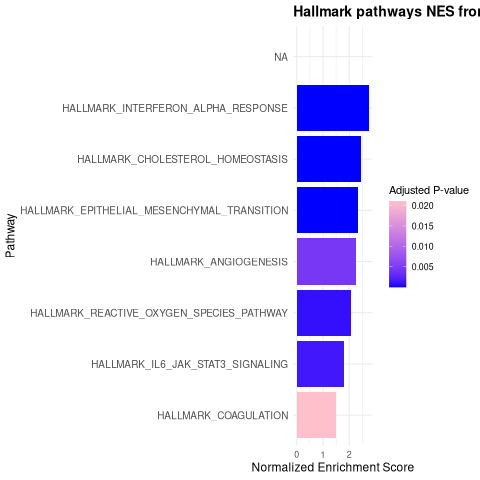

In [164]:
%%R

# Create the ggplot with a color scale for padj
ggplot(fgseaResSignificant, aes(reorder(pathway, NES), NES)) +
  geom_col(aes(fill = padj)) +
  coord_flip() +
  scale_fill_gradient(low = "blue", high = "pink", na.value = "black", name = "Adjusted P-value") +
  labs(x = "Pathway", y = "Normalized Enrichment Score",
       title = "Hallmark pathways NES from GSEA") +
  theme_minimal() +
  theme(
    axis.text.y = element_text(size = 10),
    axis.title = element_text(size = 12),
    plot.title = element_text(size = 14, face = "bold")
  )

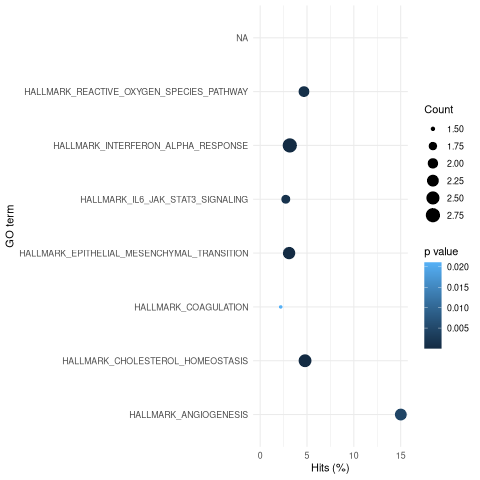

In [165]:
%%R

# Calculate hits percentage (if 'numDEInCat' and 'numInCat' equivalent are 'NES' and 'size')
fgseaResSignificant <- fgseaResSignificant %>%
  mutate(hitsPerc = NES * 100 / size)

# Ensure the columns 'padj' and 'NES' are present for the plot
fgseaResSignificant <- fgseaResSignificant %>%
  rename(term = pathway, over_represented_pvalue = padj, numDEInCat = NES)

# Create the plot
ggplot(fgseaResSignificant, aes(x = hitsPerc, y = term, colour = over_represented_pvalue, size = numDEInCat)) +
  geom_point() +
  expand_limits(x = 0) +
  labs(x = "Hits (%)", y = "GO term", colour = "p value", size = "Count") +
  theme_minimal()

#https://bioinformatics-core-shared-training.github.io/cruk-summer-school-2018/RNASeq2018/html/06_Gene_set_testing.nb.html

In [166]:
%%R

# Subset significant results
fgseaResSignificant <- fgseaResTidy[fgseaResTidy$padj < 0.05, ]

# Select columns to display and sort by padj
fgseaResSignificant <- fgseaResSignificant[, c("pathway", "padj", "NES", "size")]
fgseaResSignificant <- fgseaResSignificant[order(fgseaResSignificant$padj), ]

# Print the table
head(fgseaResSignificant)

# A tibble: 6 × 4
  pathway                                        padj   NES  size
  <chr>                                         <dbl> <dbl> <int>
1 HALLMARK_INTERFERON_ALPHA_RESPONSE         7.71e-12  2.75    87
2 HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION 8.21e- 8  2.35    76
3 HALLMARK_CHOLESTEROL_HOMEOSTASIS           1.80e- 6  2.44    51
4 HALLMARK_REACTIVE_OXYGEN_SPECIES_PATHWAY   8.31e- 4  2.06    44
5 HALLMARK_IL6_JAK_STAT3_SIGNALING           1.35e- 3  1.80    66
6 HALLMARK_ANGIOGENESIS                      4.51e- 3  2.25    15


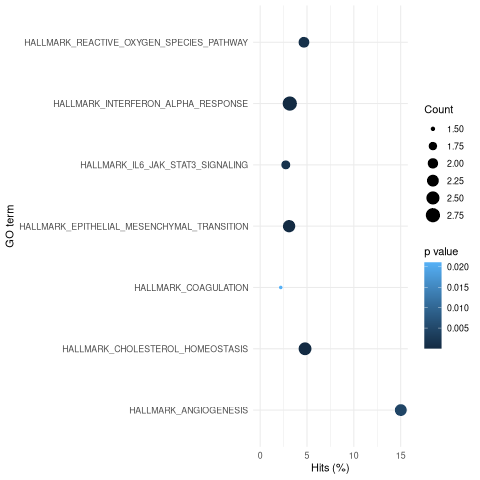

In [167]:
%%R

# Filter fgseaResSignificant to include only the main pathways from collapsedPathways
filtered_fgseaResSignificant <- fgseaResSignificant %>%
  filter(pathway %in% collapsedPathways$mainPathways)

# Calculate hits percentage
filtered_fgseaResSignificant <- filtered_fgseaResSignificant %>%
  mutate(hitsPerc = NES * 100 / size)

# Ensure the columns 'padj' and 'NES' are present for the plot
filtered_fgseaResSignificant <- filtered_fgseaResSignificant %>%
  rename(term = pathway, over_represented_pvalue = padj, numDEInCat = NES)

# Create the plot
ggplot(filtered_fgseaResSignificant, aes(x = hitsPerc, y = term, colour = over_represented_pvalue, size = numDEInCat)) +
  geom_point() +
  expand_limits(x = 0) +
  labs(x = "Hits (%)", y = "GO term", colour = "p value", size = "Count") +
  theme_minimal()


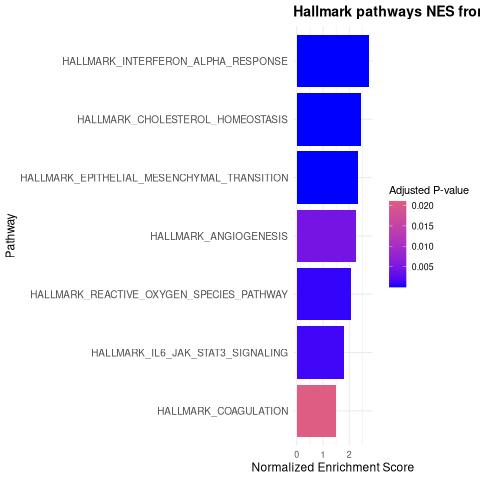

In [168]:
%%R

# Filter fgseaResSignificant to include only the main pathways from collapsedPathways
filtered_fgseaResSignificant <- fgseaResSignificant %>%
  filter(pathway %in% collapsedPathways$mainPathways)

# Create the ggplot with a color scale for padj
ggplot(filtered_fgseaResSignificant, aes(reorder(pathway, NES), NES)) +
  geom_col(aes(fill = padj)) +
  coord_flip() +
  scale_fill_gradient(low = "#0000FF", high = "#de5d83", na.value = "black", name = "Adjusted P-value") +
  labs(x = "Pathway", y = "Normalized Enrichment Score",
       title = "Hallmark pathways NES from GSEA") +
  theme_minimal() +
  theme(
    axis.text.y = element_text(size = 10),
    axis.title = element_text(size = 12),
    plot.title = element_text(size = 14, face = "bold")
  )

In [169]:
%%R

# Remove "HALLMARK_" prefix from the 'pathway' column
filtered_fgseaResSignificant$pathway <- gsub("^HALLMARK_", "", filtered_fgseaResSignificant$pathway)

# View the updated heatmap_df
head(filtered_fgseaResSignificant)

# A tibble: 6 × 4
  pathway                               padj   NES  size
  <chr>                                <dbl> <dbl> <int>
1 INTERFERON_ALPHA_RESPONSE         7.71e-12  2.75    87
2 EPITHELIAL_MESENCHYMAL_TRANSITION 8.21e- 8  2.35    76
3 CHOLESTEROL_HOMEOSTASIS           1.80e- 6  2.44    51
4 REACTIVE_OXYGEN_SPECIES_PATHWAY   8.31e- 4  2.06    44
5 IL6_JAK_STAT3_SIGNALING           1.35e- 3  1.80    66
6 ANGIOGENESIS                      4.51e- 3  2.25    15


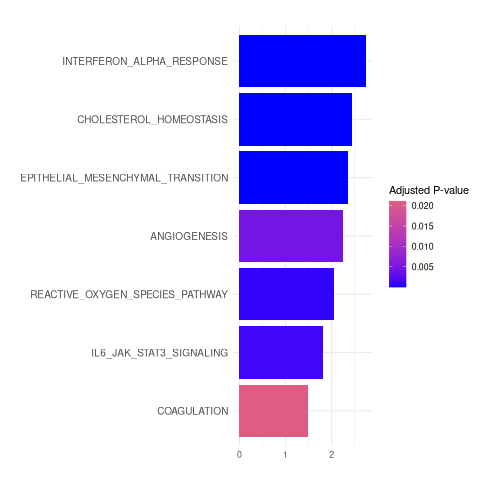

In [170]:
%%R

# Create the ggplot
plot <- ggplot(filtered_fgseaResSignificant, aes(reorder(pathway, NES), NES)) +
  geom_col(aes(fill = padj)) +
  coord_flip() +
  scale_fill_gradient(low = "#0000FF", high = "#de5d83", na.value = "black", name = "Adjusted P-value") +
  labs(x = "", y = "",
       title = "") +
  theme_minimal() +
  theme(
    axis.text.y = element_text(size = 10),
    axis.title = element_text(size = 12),
    plot.title = element_text(size = 14, face = "bold")
  )

# Save the plot as a high-resolution PNG file
#ggsave("./figures/GSEA/Cupr_demyel_DAM_hallmark_pathways_NES_GSEA.png", plot = plot, dpi = 300, width = 10, height = 8)

print(plot)

In [171]:
%%R
unique(fgsea_MOL4_significant$pathway)

[1] "HALLMARK_ANGIOGENESIS"                     
[2] "HALLMARK_CHOLESTEROL_HOMEOSTASIS"          
[3] "HALLMARK_COAGULATION"                      
[4] "HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION"
[5] "HALLMARK_IL6_JAK_STAT3_SIGNALING"          
[6] "HALLMARK_INTERFERON_ALPHA_RESPONSE"        
[7] "HALLMARK_REACTIVE_OXYGEN_SPECIES_PATHWAY"  


In [172]:
%%R

# Define the pathway of interest
pathway_of_interest <- "HALLMARK_ANGIOGENESIS"

# Subset the data to get the row with the specified pathway
selected_row <- fgsea_MOL4_significant[fgsea_MOL4_significant$pathway == pathway_of_interest, ]

# Extract the leadingEdge column as a list of gene symbols
leading_edge_genes <- unlist(selected_row$leadingEdge)

# Print the list of genes
print(leading_edge_genes)

[1] "Lpl"    "Spp1"   "Lrpap1" "Pf4"    "Ccnd2"  "Pdgfa"  "Vegfa"  "Olr1"  


In [173]:
%%R

# Define the pathway of interest
pathway_of_interest <- "HALLMARK_CHOLESTEROL_HOMEOSTASIS"

# Subset the data to get the row with the specified pathway
selected_row <- fgsea_MOL4_significant[fgsea_MOL4_significant$pathway == pathway_of_interest, ]

# Extract the leadingEdge column as a list of gene symbols
leading_edge_genes <- unlist(selected_row$leadingEdge)

# Print the list of genes
print(leading_edge_genes)

 [1] "Scd2"   "Lpl"    "Anxa5"  "Fabp5"  "Cxcl16" "Lgals3" "Cd9"    "Alcam" 
 [9] "Gusb"   "Trib3"  "Plscr1" "Ctnnb1" "Plaur"  "Nfil3"  "Ethe1"  "Pdk3"  
[17] "Fasn"   "Atf5"   "Tmem97"


In [ ]:
%%R

# Define the pathway of interest
pathway_of_interest <- "HALLMARK_IL6_JAK_STAT3_SIGNALING"

# Subset the data to get the row with the specified pathway
selected_row <- fgsea_MOL4_significant[fgsea_MOL4_significant$pathway == pathway_of_interest, ]

# Extract the leadingEdge column as a list of gene symbols
leading_edge_genes <- unlist(selected_row$leadingEdge)

# Print the list of genes
print(leading_edge_genes)

In [ ]:
%%R

# Define the pathway of interest
pathway_of_interest <- "HALLMARK_REACTIVE_OXYGEN_SPECIES_PATHWAY"

# Subset the data to get the row with the specified pathway
selected_row <- fgsea_MOL4_significant[fgsea_MOL4_significant$pathway == pathway_of_interest, ]

# Extract the leadingEdge column as a list of gene symbols
leading_edge_genes <- unlist(selected_row$leadingEdge)

# Print the list of genes
print(leading_edge_genes)

In [174]:
%%R

class(fgsea_MOL4_significant)

[1] "data.table" "data.frame"


In [175]:
%%R

fgsea_MOL4_significant <- as.data.frame(fgsea_MOL4_significant)

In [176]:
%%R
library(data.table)
fwrite(fgsea_MOL4_significant, file = "./files/filtered_fgseaResSignificant_Cupr_demyel_allgene.csv")

# Cupr_remyel_MOL

In [ ]:
%%R

# Replace the file path with the actual path if the file is not in the current directory
df <- read.csv("./files/Cupr_remyel_MG_DAM_voom_wqw.csv")
head(df)  # Display the first few rows of the data frame to confirm it's loaded correctly

In [ ]:
%%R

dim(df)

In [ ]:
%%R

my_genes <- df$gene
head(my_genes)

In [ ]:
%%R
# Check column names in the dataframe
colnames(df)

In [ ]:
%%R

# Filter the dataset for significant genes
filtered_df <- df[abs(df$logFC) >= 0.585 & df$adj.P.Val < 0.05, ]

# Compute ranking score: sign(logFC) * -log10(P.Value)
filtered_df$ranking_score <- sign(filtered_df$logFC) * -log10(filtered_df$P.Value)

# Assign names to the rankings
rankings <- filtered_df$ranking_score
names(rankings) <- filtered_df$gene

# Sort the rankings in descending order
rankings <- sort(rankings, decreasing = TRUE)

In [ ]:
%%R

# Ensure the length of the gene column matches the length of rankings
length(df$gene) == length(rankings)

In [ ]:
%%R

plot(rankings)

In [ ]:
%%R

max(rankings)

In [ ]:
%%R

min(rankings)

In [ ]:
%%R

ggplot(data.frame(gene_symbol = names(rankings)[1:50], ranks = rankings[1:50]), aes(gene_symbol, ranks)) + 
    geom_point() +
    theme_classic() + 
    theme(axis.text.x = element_text(angle = 90, vjust = 0.5, hjust=1))

# Figure out how to set up gene lists

In [ ]:
%%R
fgsea_res <- fgsea(pathways = pathwaysH, 
                  stats    = rankings,
                  scoreType = 'std',
                  minSize  = 15,
                  maxSize  = 500)

In [ ]:
%%R
fgsea_res

In [ ]:
%%R

dim(fgsea_res)

In [ ]:
%%R

library(data.table)
fwrite(fgsea_res, file = "./files/fgsea_Cupr_remyel_DAMs_allgenes.csv")

In [ ]:
%%R

# Filter for significant results with padj < 0.05
fgsea_MOL4_significant <- fgsea_res %>% filter(padj < 0.1)
dim(fgsea_MOL4_significant)

In [ ]:
%%R

head(fgsea_MOL4_significant)

In [ ]:
%%R

plotGseaTable(pathwaysH[fgsea_MOL4_significant$pathway], 
              rankings, 
              fgsea_MOL4_significant, 
              gseaParam = 0.5)

In [ ]:
%%R

topUp <- fgsea_MOL4_significant %>% 
    filter(ES > 0) %>% 
    top_n(10, wt=-padj)

topDown <- fgsea_MOL4_significant %>% 
    filter(ES < 0) %>% 
    top_n(10, wt=-padj)

topPathways <- bind_rows(topUp, topDown) %>% 
    arrange(-ES)

plotGseaTable(pathwaysH[topPathways$pathway], 
              rankings, 
              fgsea_MOL4_significant, 
              gseaParam = 0.5)

In [ ]:
%%R

collapsedPathways <- collapsePathways(fgsea_MOL4_significant[order(pval)][padj < 0.05], 
                                      pathwaysH, rankings)

In [ ]:
%%R

mainPathways <- fgsea_MOL4_significant[pathway %in% collapsedPathways$mainPathways][
                         order(-NES), pathway]
plotGseaTable(pathwaysH[mainPathways], rankings, fgsea_MOL4_significant, 
              gseaParam = 0.5)

In [ ]:
%%R

fgseaResTidy <- fgsea_res %>%
  as_tibble() %>%
  arrange(desc(NES))

In [ ]:
%%R

# Subset significant results
fgseaResSignificant <- fgseaResTidy[fgseaResTidy$padj < 0.05, ]

# Select columns to display and sort by padj
fgseaResSignificant <- fgseaResSignificant[, c("pathway", "padj", "NES", "size")]
fgseaResSignificant <- fgseaResSignificant[order(fgseaResSignificant$padj), ]

# Print the table
head(fgseaResSignificant)

In [ ]:
%%R

# Create the ggplot with a color scale for padj
ggplot(fgseaResSignificant, aes(reorder(pathway, NES), NES)) +
  geom_col(aes(fill = padj)) +
  coord_flip() +
  scale_fill_gradient(low = "blue", high = "pink", na.value = "black", name = "Adjusted P-value") +
  labs(x = "Pathway", y = "Normalized Enrichment Score",
       title = "Hallmark pathways NES from GSEA") +
  theme_minimal() +
  theme(
    axis.text.y = element_text(size = 10),
    axis.title = element_text(size = 12),
    plot.title = element_text(size = 14, face = "bold")
  )

In [ ]:
%%R

# Calculate hits percentage (if 'numDEInCat' and 'numInCat' equivalent are 'NES' and 'size')
fgseaResSignificant <- fgseaResSignificant %>%
  mutate(hitsPerc = NES * 100 / size)

# Ensure the columns 'padj' and 'NES' are present for the plot
fgseaResSignificant <- fgseaResSignificant %>%
  rename(term = pathway, over_represented_pvalue = padj, numDEInCat = NES)

# Create the plot
ggplot(fgseaResSignificant, aes(x = hitsPerc, y = term, colour = over_represented_pvalue, size = numDEInCat)) +
  geom_point() +
  expand_limits(x = 0) +
  labs(x = "Hits (%)", y = "GO term", colour = "p value", size = "Count") +
  theme_minimal()

#https://bioinformatics-core-shared-training.github.io/cruk-summer-school-2018/RNASeq2018/html/06_Gene_set_testing.nb.html

In [ ]:
%%R

# Subset significant results
fgseaResSignificant <- fgseaResTidy[fgseaResTidy$padj < 0.05, ]

# Select columns to display and sort by padj
fgseaResSignificant <- fgseaResSignificant[, c("pathway", "padj", "NES", "size")]
fgseaResSignificant <- fgseaResSignificant[order(fgseaResSignificant$padj), ]

# Print the table
head(fgseaResSignificant)

In [ ]:
%%R

# Filter fgseaResSignificant to include only the main pathways from collapsedPathways
filtered_fgseaResSignificant <- fgseaResSignificant %>%
  filter(pathway %in% collapsedPathways$mainPathways)

# Calculate hits percentage
filtered_fgseaResSignificant <- filtered_fgseaResSignificant %>%
  mutate(hitsPerc = NES * 100 / size)

# Ensure the columns 'padj' and 'NES' are present for the plot
filtered_fgseaResSignificant <- filtered_fgseaResSignificant %>%
  rename(term = pathway, over_represented_pvalue = padj, numDEInCat = NES)

# Create the plot
ggplot(filtered_fgseaResSignificant, aes(x = hitsPerc, y = term, colour = over_represented_pvalue, size = numDEInCat)) +
  geom_point() +
  expand_limits(x = 0) +
  labs(x = "Hits (%)", y = "GO term", colour = "p value", size = "Count") +
  theme_minimal()


In [ ]:
%%R

# Filter fgseaResSignificant to include only the main pathways from collapsedPathways
filtered_fgseaResSignificant <- fgseaResSignificant %>%
  filter(pathway %in% collapsedPathways$mainPathways)

# Create the ggplot with a color scale for padj
ggplot(filtered_fgseaResSignificant, aes(reorder(pathway, NES), NES)) +
  geom_col(aes(fill = padj)) +
  coord_flip() +
  scale_fill_gradient(low = "#0000FF", high = "#de5d83", na.value = "black", name = "Adjusted P-value") +
  labs(x = "Pathway", y = "Normalized Enrichment Score",
       title = "Hallmark pathways NES from GSEA") +
  theme_minimal() +
  theme(
    axis.text.y = element_text(size = 10),
    axis.title = element_text(size = 12),
    plot.title = element_text(size = 14, face = "bold")
  )

In [ ]:
%%R

# Remove "HALLMARK_" prefix from the 'pathway' column
filtered_fgseaResSignificant$pathway <- gsub("^HALLMARK_", "", filtered_fgseaResSignificant$pathway)

# View the updated heatmap_df
head(filtered_fgseaResSignificant)

In [ ]:
%%R

# Create the ggplot
plot <- ggplot(filtered_fgseaResSignificant, aes(reorder(pathway, NES), NES)) +
  geom_col(aes(fill = padj)) +
  coord_flip() +
  scale_fill_gradient(low = "#0000FF", high = "#de5d83", na.value = "black", name = "Adjusted P-value") +
  labs(x = "", y = "",
       title = "") +
  theme_minimal() +
  theme(
    axis.text.y = element_text(size = 10),
    axis.title = element_text(size = 12),
    plot.title = element_text(size = 14, face = "bold")
  )

# Save the plot as a high-resolution PNG file
#ggsave("./figures/GSEA/Cupr_remyel_DAM_hallmark_pathways_NES_GSEA.png", plot = plot, dpi = 300, width = 10, height = 8)

print(plot)

In [ ]:
%%R
unique(fgsea_MOL4_significant$pathway)

In [ ]:
%%R

# Define the pathway of interest
pathway_of_interest <- "HALLMARK_CHOLESTEROL_HOMEOSTASIS"

# Subset the data to get the row with the specified pathway
selected_row <- fgsea_MOL4_significant[fgsea_MOL4_significant$pathway == pathway_of_interest, ]

# Extract the leadingEdge column as a list of gene symbols
leading_edge_genes <- unlist(selected_row$leadingEdge)

# Print the list of genes
print(leading_edge_genes)

In [ ]:
%%R

# Define the pathway of interest
pathway_of_interest <- "HALLMARK_IL2_STAT5_SIGNALING"

# Subset the data to get the row with the specified pathway
selected_row <- fgsea_MOL4_significant[fgsea_MOL4_significant$pathway == pathway_of_interest, ]

# Extract the leadingEdge column as a list of gene symbols
leading_edge_genes <- unlist(selected_row$leadingEdge)

# Print the list of genes
print(leading_edge_genes)

In [ ]:
%%R

# Define the pathway of interest
pathway_of_interest <- "HALLMARK_IL6_JAK_STAT3_SIGNALING"

# Subset the data to get the row with the specified pathway
selected_row <- fgsea_MOL4_significant[fgsea_MOL4_significant$pathway == pathway_of_interest, ]

# Extract the leadingEdge column as a list of gene symbols
leading_edge_genes <- unlist(selected_row$leadingEdge)

# Print the list of genes
print(leading_edge_genes)

In [ ]:
%%R

# Define the pathway of interest
pathway_of_interest <- "HALLMARK_INTERFERON_ALPHA_RESPONSE"

# Subset the data to get the row with the specified pathway
selected_row <- fgsea_MOL4_significant[fgsea_MOL4_significant$pathway == pathway_of_interest, ]

# Extract the leadingEdge column as a list of gene symbols
leading_edge_genes <- unlist(selected_row$leadingEdge)

# Print the list of genes
print(leading_edge_genes)

In [ ]:
%%R

# Define the pathway of interest
pathway_of_interest <- "HALLMARK_INTERFERON_GAMMA_RESPONSE"

# Subset the data to get the row with the specified pathway
selected_row <- fgsea_MOL4_significant[fgsea_MOL4_significant$pathway == pathway_of_interest, ]

# Extract the leadingEdge column as a list of gene symbols
leading_edge_genes <- unlist(selected_row$leadingEdge)

# Print the list of genes
print(leading_edge_genes)

In [ ]:
%%R

# Define the pathway of interest
pathway_of_interest <- "HALLMARK_TNFA_SIGNALING_VIA_NFKB"

# Subset the data to get the row with the specified pathway
selected_row <- fgsea_MOL4_significant[fgsea_MOL4_significant$pathway == pathway_of_interest, ]

# Extract the leadingEdge column as a list of gene symbols
leading_edge_genes <- unlist(selected_row$leadingEdge)

# Print the list of genes
print(leading_edge_genes)

In [ ]:
%%R

# Define the pathway of interest
pathway_of_interest <- "HALLMARK_KRAS_SIGNALING_UP"

# Subset the data to get the row with the specified pathway
selected_row <- fgsea_MOL4_significant[fgsea_MOL4_significant$pathway == pathway_of_interest, ]

# Extract the leadingEdge column as a list of gene symbols
leading_edge_genes <- unlist(selected_row$leadingEdge)

# Print the list of genes
print(leading_edge_genes)

In [ ]:
%%R

fgsea_MOL4_significant <- as.data.frame(fgsea_MOL4_significant)

In [ ]:
%%R
library(data.table)
fwrite(fgsea_MOL4_significant, file = "./files/filtered_fgseaResSignificant_Cupr_remyel_DAMs.csv")

# Combined dot plot

In [4]:
%%R

# Load the data.table package
library(data.table)

# Read the files back into R
LPC_de_F <- fread("./files/filtered_fgsea_LPC_demyel_BAM_significant_allgene.csv")
LPC_de_E <- fread("./files/filtered_fgseaResSignificant_LPC_demyel_allgene.csv")
LPC_re_E <- fread("./files/filtered_fgseaResSignificant_LPC_remyel_allgene.csv")
Cupr_de_G <- fread("./files/filtered_fgseaResSignificant_Cupr_demyel_allgene.csv")

data.table 1.16.4 using 1 threads (see ?getDTthreads).  Latest news: r-datatable.com

Attaching package: ‘data.table’

The following objects are masked from ‘package:lubridate’:

    hour, isoweek, mday, minute, month, quarter, second, wday, week,
    yday, year

The following objects are masked from ‘package:dplyr’:

    between, first, last

The following object is masked from ‘package:purrr’:

    transpose



In [5]:
%%R

# Subset the data frames to include only pathway, padj, NES, and size
subset_columns <- c("pathway", "NES", "padj")

#OPC_de_subset <- OPC_de[, ..subset_columns]
LPC_de_F_subset <- LPC_de_F[, ..subset_columns]
LPC_de_E_subset <- LPC_de_E[, ..subset_columns]
LPC_re_E_subset <- LPC_re_E[, ..subset_columns]
Cupr_de_G_subset <- Cupr_de_G[, ..subset_columns]

In [6]:
%%R

# Combine the 'pathway' columns from all the data frames
all_pathways <- unique(c(LPC_de_F$pathway, LPC_de_E$pathway,
                        LPC_re_E$pathway, Cupr_de_G$pathway))

# Verify the unique pathways
print(head(all_pathways))

# Check the total number of unique pathways
length(all_pathways)

[1] "CHOLESTEROL_HOMEOSTASIS"           "EPITHELIAL_MESENCHYMAL_TRANSITION"
[3] "KRAS_SIGNALING_DN"                 "MITOTIC_SPINDLE"                  
[5] "REACTIVE_OXYGEN_SPECIES_PATHWAY"   "TNFA_SIGNALING_VIA_NFKB"          
[1] 34


In [7]:
%%R
# Function to ensure each data frame includes all pathways and fills missing ones with NaN
fill_missing_pathways <- function(df, all_pathways) {
  # Identify pathways that are missing in the current data frame
  missing_pathways <- setdiff(all_pathways, df$pathway)
  
  # Create a data frame with missing pathways, NES and padj set to NaN
  missing_data <- data.frame(pathway = missing_pathways, 
                             NES = rep(NaN, length(missing_pathways)), 
                             padj = rep(NaN, length(missing_pathways)))
  
  # Combine the original data frame with the missing pathways
  df <- rbind(df[, c("pathway", "NES", "padj")], missing_data)
  
  # Sort by pathway to maintain a consistent order
  df <- df[order(df$pathway), ]
  
  return(df)
}

# Combine the 'pathway' columns from all the data frames
all_pathways <- unique(c(LPC_de_F$pathway, LPC_de_E$pathway,
                        LPC_re_E$pathway, Cupr_de_G$pathway))

# Apply the function to all data frames
#OPC_de_filtered <- fill_missing_pathways(OPC_de_subset, all_pathways)
LPC_de_F_filtered <- fill_missing_pathways(LPC_de_F_subset, all_pathways)
LPC_de_E_filtered <- fill_missing_pathways(LPC_de_E_subset, all_pathways)
LPC_re_E_filtered <- fill_missing_pathways(LPC_re_E_subset, all_pathways)
Cupr_de_G_filtered <- fill_missing_pathways(Cupr_de_G_subset, all_pathways)

In [8]:
%%R

LPC_de_F_filtered$condition <- "LPC_de_PMs"
LPC_de_E_filtered$condition <- "LPC_de_DAMs"
LPC_re_E_filtered$condition <- "LPC_re_DAMs"
Cupr_de_G_filtered$condition <- "Cupr_de_DAMs"

# Combine all datasets into a single dataframe
combined_df <- rbind(LPC_de_F_filtered, LPC_de_E_filtered,
                    LPC_re_E_filtered, Cupr_de_G_filtered)

# Verify the structure
head(combined_df)

                             pathway      NES        padj  condition
                              <char>    <num>       <num>     <char>
1:           CHOLESTEROL_HOMEOSTASIS 1.925241 0.002329538 LPC_de_PMs
2: EPITHELIAL_MESENCHYMAL_TRANSITION 1.414189 0.046930680 LPC_de_PMs
3:        HALLMARK_ANDROGEN_RESPONSE      NaN         NaN LPC_de_PMs
4:             HALLMARK_ANGIOGENESIS      NaN         NaN LPC_de_PMs
5:                HALLMARK_APOPTOSIS      NaN         NaN LPC_de_PMs
6:  HALLMARK_CHOLESTEROL_HOMEOSTASIS      NaN         NaN LPC_de_PMs


In [9]:
%%R

# Remove "HALLMARK_" prefix from the 'pathway' column
combined_df$pathway <- gsub("^HALLMARK_", "", combined_df$pathway)

# View the updated heatmap_df
head(combined_df)

                             pathway      NES        padj  condition
                              <char>    <num>       <num>     <char>
1:           CHOLESTEROL_HOMEOSTASIS 1.925241 0.002329538 LPC_de_PMs
2: EPITHELIAL_MESENCHYMAL_TRANSITION 1.414189 0.046930680 LPC_de_PMs
3:                 ANDROGEN_RESPONSE      NaN         NaN LPC_de_PMs
4:                      ANGIOGENESIS      NaN         NaN LPC_de_PMs
5:                         APOPTOSIS      NaN         NaN LPC_de_PMs
6:           CHOLESTEROL_HOMEOSTASIS      NaN         NaN LPC_de_PMs


In [10]:
%%R

# Transform padj to -log10 for better visualization
combined_df$log_padj <- -log10(combined_df$padj)

In addition: Warning message:
Removed 90 rows containing missing values or values outside the scale range
(`geom_point()`). 


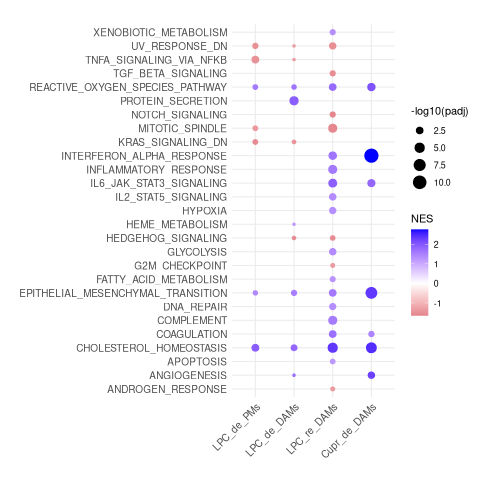

In [11]:
%%R

library(ggplot2)

# Set the factor levels for conditions to control the order
combined_df$condition <- factor(combined_df$condition, 
                                 levels = c("LPC_de_PMs", "LPC_de_DAMs", "LPC_re_DAMs",
                                           "Cupr_de_DAMs"))

# Create the dotplot with switched axes and assign to heatmap_plot
heatmap_plot <- ggplot(combined_df, aes(y = pathway, x = condition, size = log_padj, color = NES)) +
  geom_point() +
  scale_color_gradient2(low = "#c32148", mid = "white", high = "#0000FF", midpoint = 0) +
  theme_minimal() +
  theme(axis.text.y = element_text(size = 10), # Adjust pathway text size for readability
        axis.text.x = element_text(angle = 45, hjust = 1, size = 10)) + # Adjust condition text
  labs(x = "", y = "", 
       size = "-log10(padj)", color = "NES", 
       title = "")

# Show the plot
print(heatmap_plot)

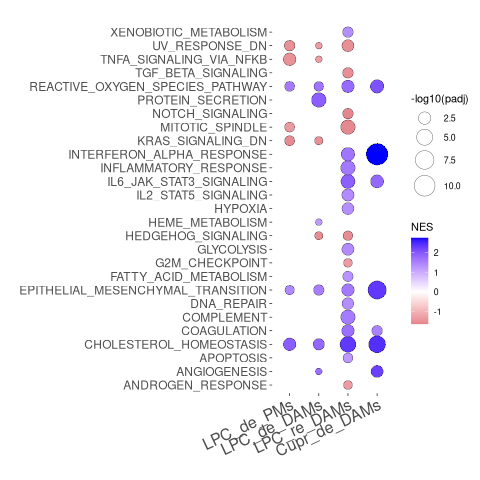

In [12]:
%%R

# Remove rows with missing or NaN values in `log_padj` or `NES`
filtered_df <- combined_df[!is.na(combined_df$log_padj) & !is.na(combined_df$NES), ]

# Set the factor levels for conditions to control the order
combined_df$condition <- factor(combined_df$condition, 
                                 levels = c("LPC_de_PMs", "LPC_de_DAMs", "LPC_re_DAMs",
                                           "Cupr_de_DAMs"))

# Create the dotplot with adjustments
heatmap_plot <- ggplot(filtered_df, aes(y = pathway, x = condition, size = log_padj, fill = NES)) +
  geom_point(shape = 21, stroke = 0.2, color = "black") + # Add thin black outline to dots
  scale_fill_gradient2(low = "#c32148", mid = "white", high = "#0000FF", midpoint = 0) +
  scale_size_continuous(range = c(3, 10)) + # Increase size of dots (min=3, max=10)
  theme_minimal() +
  theme(
    panel.grid = element_blank(), # Remove grid lines
    axis.text.y = element_text(size = 12), # Adjust pathway text size
    axis.text.x = element_text(angle = 25, hjust = 1, size = 16, vjust = 1), # Adjust x-axis text spacing
    axis.ticks = element_line(linewidth = 0.3) # Adjust x-axis ticks with `linewidth`
  ) +
  labs(
    x = "", 
    y = "", 
    size = "-log10(padj)", 
    fill = "NES", 
    title = ""
  )

# Display the plot
print(heatmap_plot)

# Save the plot
#ggsave("./figures/GSEA/heatmap_pathway_NES_padj_ALL_only.png", plot = heatmap_plot, dpi = 300, width = 10, height = 8)

In [13]:
%%R
print(unique(filtered_df$pathway))

 [1] "CHOLESTEROL_HOMEOSTASIS"           "EPITHELIAL_MESENCHYMAL_TRANSITION"
 [3] "KRAS_SIGNALING_DN"                 "MITOTIC_SPINDLE"                  
 [5] "REACTIVE_OXYGEN_SPECIES_PATHWAY"   "TNFA_SIGNALING_VIA_NFKB"          
 [7] "UV_RESPONSE_DN"                    "ANGIOGENESIS"                     
 [9] "HEDGEHOG_SIGNALING"                "HEME_METABOLISM"                  
[11] "PROTEIN_SECRETION"                 "ANDROGEN_RESPONSE"                
[13] "APOPTOSIS"                         "COAGULATION"                      
[15] "COMPLEMENT"                        "DNA_REPAIR"                       
[17] "FATTY_ACID_METABOLISM"             "G2M_CHECKPOINT"                   
[19] "GLYCOLYSIS"                        "HYPOXIA"                          
[21] "IL2_STAT5_SIGNALING"               "IL6_JAK_STAT3_SIGNALING"          
[23] "INFLAMMATORY_RESPONSE"             "INTERFERON_ALPHA_RESPONSE"        
[25] "NOTCH_SIGNALING"                   "TGF_BETA_SIGNALING"               

In [14]:
%%R

pathway_order <- filtered_df %>%
  group_by(pathway) %>%
  summarise(
    n_up = sum(NES > 0),      # number of conditions where NES > 0
    n_down = sum(NES < 0)     # optional, if you care about downregulated too
  ) %>%
  arrange(desc(n_up))         # order pathways by how many are "up"

In [15]:
%%R
filtered_df <- filtered_df %>%
  mutate(pathway = factor(pathway, levels = pathway_order$pathway))

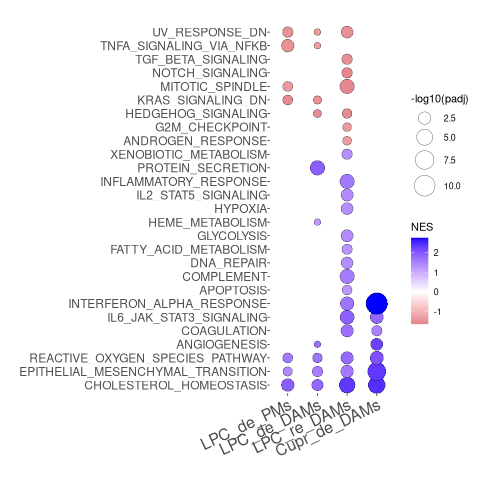

In [16]:
%%R
heatmap_plot <- ggplot(filtered_df, aes(y = pathway, x = condition, size = log_padj, fill = NES)) +
  geom_point(shape = 21, stroke = 0.2, color = "black") +
  scale_fill_gradient2(low = "#c32148", mid = "white", high = "#0000FF", midpoint = 0) +
  scale_size_continuous(range = c(3, 10)) +
  theme_minimal() +
  theme(
    panel.grid = element_blank(),
    axis.text.y = element_text(size = 12, margin = margin(t = 5, b = 5)),
    axis.text.x = element_text(angle = 25, hjust = 1, size = 16, vjust = 1),
    axis.ticks = element_line(linewidth = 0.3)
  ) +
  labs(
    x = "", 
    y = "", 
    size = "-log10(padj)", 
    fill = "NES", 
    title = ""
  )

print(heatmap_plot)

In [17]:
%%R
# Or, if you just want the ordered names:
ordered_pathways <- pathway_order$pathway
print(ordered_pathways)

 [1] "CHOLESTEROL_HOMEOSTASIS"           "EPITHELIAL_MESENCHYMAL_TRANSITION"
 [3] "REACTIVE_OXYGEN_SPECIES_PATHWAY"   "ANGIOGENESIS"                     
 [5] "COAGULATION"                       "IL6_JAK_STAT3_SIGNALING"          
 [7] "INTERFERON_ALPHA_RESPONSE"         "APOPTOSIS"                        
 [9] "COMPLEMENT"                        "DNA_REPAIR"                       
[11] "FATTY_ACID_METABOLISM"             "GLYCOLYSIS"                       
[13] "HEME_METABOLISM"                   "HYPOXIA"                          
[15] "IL2_STAT5_SIGNALING"               "INFLAMMATORY_RESPONSE"            
[17] "PROTEIN_SECRETION"                 "XENOBIOTIC_METABOLISM"            
[19] "ANDROGEN_RESPONSE"                 "G2M_CHECKPOINT"                   
[21] "HEDGEHOG_SIGNALING"                "KRAS_SIGNALING_DN"                
[23] "MITOTIC_SPINDLE"                   "NOTCH_SIGNALING"                  
[25] "TGF_BETA_SIGNALING"                "TNFA_SIGNALING_VIA_NFKB"          

In [18]:
%%R

desired_pathway_order <- c(
  "CHOLESTEROL_HOMEOSTASIS",
  "EPITHELIAL_MESENCHYMAL_TRANSITION",
  "REACTIVE_OXYGEN_SPECIES_PATHWAY",
  "ANGIOGENESIS",
  "INTERFERON_ALPHA_RESPONSE",
  "IL6_JAK_STAT3_SIGNALING",
  "COAGULATION",
  "PROTEIN_SECRETION",
  "HEME_METABOLISM",
  "COMPLEMENT",
  "INFLAMMATORY_RESPONSE",
  "IL2_STAT5_SIGNALING",
  "HYPOXIA",
  "GLYCOLYSIS",
  "DNA_REPAIR",
  "FATTY_ACID_METABOLISM",
  "APOPTOSIS",
  "XENOBIOTIC_METABOLISM",
  "HEDGEHOG_SIGNALING",
  "UV_RESPONSE_DN",
  "KRAS_SIGNALING_DN",
  "TNFA_SIGNALING_VIA_NFKB",
  "MITOTIC_SPINDLE",
  "NOTCH_SIGNALING",
  "TGF_BETA_SIGNALING",
  "G2M_CHECKPOINT",
  "ANDROGEN_RESPONSE"
)
 

# Reorder the 'pathway' column in filtered_df
filtered_df$pathway <- factor(filtered_df$pathway, levels = desired_pathway_order)

# Verify the order
print(levels(filtered_df$pathway))

 [1] "CHOLESTEROL_HOMEOSTASIS"           "EPITHELIAL_MESENCHYMAL_TRANSITION"
 [3] "REACTIVE_OXYGEN_SPECIES_PATHWAY"   "ANGIOGENESIS"                     
 [5] "INTERFERON_ALPHA_RESPONSE"         "IL6_JAK_STAT3_SIGNALING"          
 [7] "COAGULATION"                       "PROTEIN_SECRETION"                
 [9] "HEME_METABOLISM"                   "COMPLEMENT"                       
[11] "INFLAMMATORY_RESPONSE"             "IL2_STAT5_SIGNALING"              
[13] "HYPOXIA"                           "GLYCOLYSIS"                       
[15] "DNA_REPAIR"                        "FATTY_ACID_METABOLISM"            
[17] "APOPTOSIS"                         "XENOBIOTIC_METABOLISM"            
[19] "HEDGEHOG_SIGNALING"                "UV_RESPONSE_DN"                   
[21] "KRAS_SIGNALING_DN"                 "TNFA_SIGNALING_VIA_NFKB"          
[23] "MITOTIC_SPINDLE"                   "NOTCH_SIGNALING"                  
[25] "TGF_BETA_SIGNALING"                "G2M_CHECKPOINT"                   

In [19]:
%%R
# Reverse the desired pathway order
reversed_pathway_order <- rev(desired_pathway_order)

# Reorder the 'pathway' column in filtered_df
filtered_df$pathway <- factor(filtered_df$pathway, levels = reversed_pathway_order)

# Verify the reversed order
print(levels(filtered_df$pathway))

 [1] "ANDROGEN_RESPONSE"                 "G2M_CHECKPOINT"                   
 [3] "TGF_BETA_SIGNALING"                "NOTCH_SIGNALING"                  
 [5] "MITOTIC_SPINDLE"                   "TNFA_SIGNALING_VIA_NFKB"          
 [7] "KRAS_SIGNALING_DN"                 "UV_RESPONSE_DN"                   
 [9] "HEDGEHOG_SIGNALING"                "XENOBIOTIC_METABOLISM"            
[11] "APOPTOSIS"                         "FATTY_ACID_METABOLISM"            
[13] "DNA_REPAIR"                        "GLYCOLYSIS"                       
[15] "HYPOXIA"                           "IL2_STAT5_SIGNALING"              
[17] "INFLAMMATORY_RESPONSE"             "COMPLEMENT"                       
[19] "HEME_METABOLISM"                   "PROTEIN_SECRETION"                
[21] "COAGULATION"                       "IL6_JAK_STAT3_SIGNALING"          
[23] "INTERFERON_ALPHA_RESPONSE"         "ANGIOGENESIS"                     
[25] "REACTIVE_OXYGEN_SPECIES_PATHWAY"   "EPITHELIAL_MESENCHYMAL_TRANSITION"

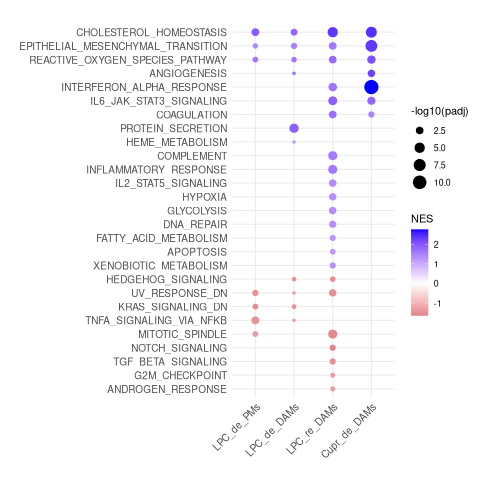

In [20]:
%%R

# Create the dotplot with switched axes and assign to heatmap_plot
heatmap_plot <- ggplot(filtered_df, aes(y = pathway, x = condition, size = log_padj, color = NES)) +
  geom_point() +
  scale_color_gradient2(low = "#c32148", mid = "white", high = "#0000FF", midpoint = 0) +
  theme_minimal() +
  theme(axis.text.y = element_text(size = 10), # Adjust pathway text size for readability
        axis.text.x = element_text(angle = 45, hjust = 1, size = 10)) + # Adjust condition text
  labs(x = "", y = "", 
       size = "-log10(padj)", color = "NES", 
       title = "")

# Show the plot
print(heatmap_plot)

 [1] "Androgen Response"                 "G2/M Checkpoint"                  
 [3] "TGF-β Signaling"                   "Notch Signaling"                  
 [5] "Mitotic Spindle"                   "TNFα Signaling via NF-κB"         
 [7] "KRAS Signaling (Down)"             "UV Response (Down)"               
 [9] "Hedgehog Signaling"                "Xenobiotic Metabolism"            
[11] "Apoptosis"                         "Fatty Acid Metabolism"            
[13] "DNA Repair"                        "Glycolysis"                       
[15] "Hypoxia"                           "IL-2/STAT5 Signaling"             
[17] "Inflammatory Response"             "Complement"                       
[19] "Heme Metabolism"                   "Protein Secretion"                
[21] "Coagulation"                       "IL-6/JAK/STAT3 Signaling"         
[23] "Interferon-α Response"             "Angiogenesis"                     
[25] "Reactive Oxygen Species Pathway"   "Epithelial-Mesenchymal Transition"

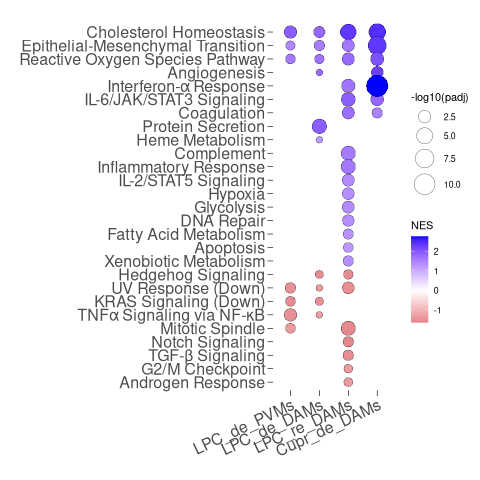

In [21]:
%%R

filtered_df$condition <- gsub("PM", "PVM", filtered_df$condition)

# Define formatted pathway names dictionary
pathway_name_format <- c(
  "CHOLESTEROL_HOMEOSTASIS"           = "Cholesterol Homeostasis",
  "EPITHELIAL_MESENCHYMAL_TRANSITION" = "Epithelial-Mesenchymal Transition",
  "REACTIVE_OXYGEN_SPECIES_PATHWAY"   = "Reactive Oxygen Species Pathway",
  "ANGIOGENESIS"                      = "Angiogenesis",
  "INTERFERON_ALPHA_RESPONSE"         = "Interferon-α Response",
  "IL6_JAK_STAT3_SIGNALING"           = "IL-6/JAK/STAT3 Signaling",
  "COAGULATION"                       = "Coagulation",
  "PROTEIN_SECRETION"                 = "Protein Secretion",
  "HEME_METABOLISM"                   = "Heme Metabolism",
  "COMPLEMENT"                        = "Complement",
  "INFLAMMATORY_RESPONSE"             = "Inflammatory Response",
  "IL2_STAT5_SIGNALING"               = "IL-2/STAT5 Signaling",
  "HYPOXIA"                           = "Hypoxia",
  "GLYCOLYSIS"                        = "Glycolysis",
  "DNA_REPAIR"                        = "DNA Repair",
  "FATTY_ACID_METABOLISM"             = "Fatty Acid Metabolism",
  "APOPTOSIS"                         = "Apoptosis",
  "XENOBIOTIC_METABOLISM"             = "Xenobiotic Metabolism",
  "HEDGEHOG_SIGNALING"                = "Hedgehog Signaling",
  "UV_RESPONSE_DN"                    = "UV Response (Down)",
  "KRAS_SIGNALING_DN"                 = "KRAS Signaling (Down)",
  "TNFA_SIGNALING_VIA_NFKB"           = "TNFα Signaling via NF-κB",
  "MITOTIC_SPINDLE"                   = "Mitotic Spindle",
  "NOTCH_SIGNALING"                   = "Notch Signaling",
  "TGF_BETA_SIGNALING"                = "TGF-β Signaling",
  "G2M_CHECKPOINT"                    = "G2/M Checkpoint",
  "ANDROGEN_RESPONSE"                 = "Androgen Response"
)

# Reverse the desired pathway order
reversed_pathway_order <- rev(desired_pathway_order)

# Add formatted pathway names to the dataframe
filtered_df$formatted_pathway <- pathway_name_format[as.character(filtered_df$pathway)]

# Reorder the 'formatted_pathway' column based on reversed pathway order
filtered_df$formatted_pathway <- factor(filtered_df$formatted_pathway, levels = pathway_name_format[reversed_pathway_order])

# Verify the new order
print(levels(filtered_df$formatted_pathway))

# Set the factor levels for conditions to control the order
filtered_df$condition <- factor(filtered_df$condition, 
                                 levels = c("LPC_de_PVMs", "LPC_de_DAMs", "LPC_re_DAMs",
                                           "Cupr_de_DAMs"))

# Create the heatmap plot
heatmap_plot <- ggplot(filtered_df, aes(y = formatted_pathway, x = condition, size = log_padj, fill = NES)) +
  geom_point(shape = 21, stroke = 0.2, color = "black") +
  scale_fill_gradient2(low = "#c32148", mid = "white", high = "#0000FF", midpoint = 0) +
  scale_size_continuous(range = c(3, 10)) +
  theme_minimal() +
  theme(
    panel.grid = element_blank(),
    axis.text.y = element_text(size = 16, vjust = 0.5),
    axis.text.x = element_text(angle = 25, hjust = 1, size = 16, vjust = 1),
    axis.ticks = element_line(linewidth = 0.3),
    axis.ticks.length = unit(0.2, "cm")
  ) +
  labs(
    x = "", 
    y = "", 
    size = "-log10(padj)", 
    fill = "NES", 
    title = ""
  )

# Print the heatmap
print(heatmap_plot)

# Save the heatmap plot
#ggsave("./figures/GSEA/heatmap_pathway_NES_padj_MG_only_ordered.png", plot = heatmap_plot, dpi = 300, width = 8.5, height = 8)

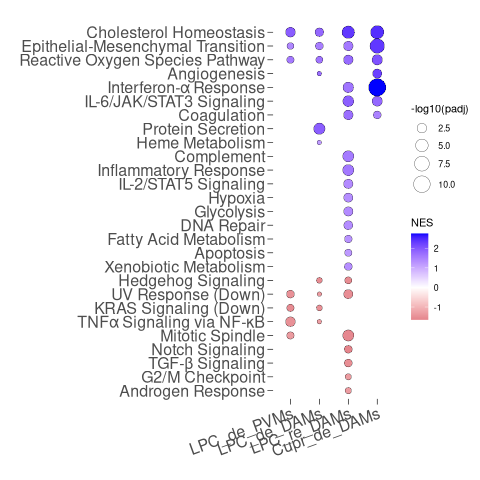

In [22]:
%%R

# Create the heatmap plot
heatmap_plot <- ggplot(filtered_df, aes(y = formatted_pathway, x = condition, size = log_padj, fill = NES)) +
  geom_point(shape = 21, stroke = 0.2, color = "black") +
  scale_fill_gradient2(low = "#c32148", mid = "white", high = "#0000FF", midpoint = 0) +
  scale_size_continuous(range = c(2, 8)) +
  theme_minimal() +
  theme(
    panel.grid = element_blank(),
    axis.text.y = element_text(size = 16, vjust = 0.5),
    axis.text.x = element_text(angle = 20, hjust = 1, size = 16, vjust = 1),
    axis.ticks = element_line(linewidth = 0.3),
    axis.ticks.length = unit(0.2, "cm")
  ) +
  labs(
    x = "", 
    y = "", 
    size = "-log10(padj)", 
    fill = "NES", 
    title = ""
  )

# Print the heatmap
print(heatmap_plot)

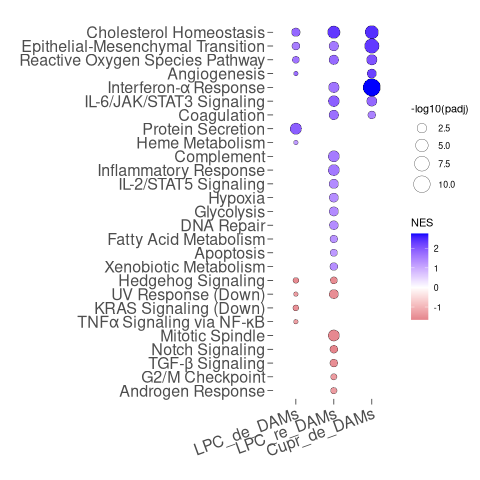

In [23]:
%%R

# Remove the "LPC_de_PVMs" condition from the dataset
filtered_df_mg <- filtered_df[filtered_df$condition != "LPC_de_PVMs", ]

# Or using dplyr (same effect)
# library(dplyr)
# filtered_df <- filtered_df %>% filter(condition != "LPC_de_PVMs")

# Now plot again
heatmap_plot <- ggplot(filtered_df_mg, aes(y = formatted_pathway, x = condition, size = log_padj, fill = NES)) +
  geom_point(shape = 21, stroke = 0.2, color = "black") +
  scale_fill_gradient2(low = "#c32148", mid = "white", high = "#0000FF", midpoint = 0) +
  scale_size_continuous(range = c(2, 8)) +
  theme_minimal() +
  theme(
    panel.grid = element_blank(),
    axis.text.y = element_text(size = 16, vjust = 0.5),
    axis.text.x = element_text(angle = 20, hjust = 1, size = 16, vjust = 1),
    axis.ticks = element_line(linewidth = 0.3),
    axis.ticks.length = unit(0.2, "cm")
  ) +
  labs(
    x = "", 
    y = "", 
    size = "-log10(padj)", 
    fill = "NES", 
    title = ""
  )

# Print the heatmap
print(heatmap_plot)

In [24]:
%%R
filtered_df_mg$condition <- gsub("LPC_de_DAMs", "LPC_demyel", filtered_df_mg$condition)
filtered_df_mg$condition <- gsub("LPC_re_DAMs", "LPC_remyel", filtered_df_mg$condition)
filtered_df_mg$condition <- gsub("Cupr_de_DAMs", "CPZ_demyel", filtered_df_mg$condition)

In [25]:
%%R
# Set the factor levels for conditions to control the order
filtered_df_mg$condition <- factor(filtered_df_mg$condition, 
                                 levels = c("LPC_demyel", "LPC_remyel", "CPZ_demyel"))

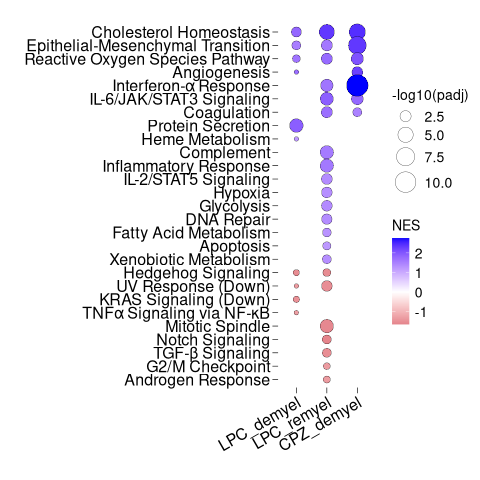

In [27]:
%%R

# Create the heatmap plot
heatmap_plot <- ggplot(filtered_df_mg, aes(y = formatted_pathway, x = condition, size = log_padj, fill = NES)) +
  geom_point(shape = 21, stroke = 0.2, color = "black") +
  scale_fill_gradient2(low = "#c32148", mid = "white", high = "#0000FF", midpoint = 0) +
  scale_size_continuous(range = c(2, 10)) +
  theme_minimal() +
  theme(
    panel.grid = element_blank(),
    axis.text.y = element_text(size = 16, vjust = 0.5, colour = "black"),
    axis.text.x = element_text(angle = 30, hjust = 1, size = 16, vjust = 1, colour = "black"),
    axis.title.x = element_text(size = 16, colour = "black"),
    axis.title.y = element_text(size = 16, colour = "black"),
    axis.ticks = element_line(linewidth = 0.3),
    axis.ticks.length = unit(0.2, "cm"),
    legend.text = element_text(colour = "black", size = 14),
    legend.title = element_text(colour = "black", size = 14)
  ) +
  labs(
    x = "", 
    y = "", 
    size = "-log10(padj)", 
    fill = "NES", 
    title = ""
  )

# Print the heatmap
print(heatmap_plot)

# Save the heatmap plot
ggsave(
  "./figures/GSEA/heatmap_pathway_NES_padj_MG_ordered_allgenes.png",
  plot = heatmap_plot,
  dpi = 300,
  width = 7.5,
  height = 8
)